# No-control random-initialization learning, then aligned controlled evaluation

This notebook learns the graph identifier from many **no-control** rollouts, each started from a fresh bounded random initial state.  
Each training repeat uses **one campaign only** for data collection.  
After learning, the **final learned model** is evaluated under control exactly as before:
- learned control
- oracle control
- no control

A dedicated sanity-check cell is included to inspect the training initial states and their coverage of the opinion range.

**Oracle-control fix:** evaluation uses aligned campaign behavior: learned, oracle, uniform, and anti-centrality controllers may all act at campaign 0 from the same `x0_eval`. Use `EVAL_ZERO_FIRST_CAMPAIGN=True` only for an explicit passive-first-campaign ablation.


In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os
import sys

def get_dir_n_levels_up(path, n):
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
if proj_root not in sys.path:
    sys.path.append(proj_root)

print("proj_root:", proj_root)

proj_root: d:\Work\repos\RL\unknown_graph_networks


In [12]:
# =========================================================
# Imports + helpers
# =========================================================

import contextlib
import io
import time
from typing import Any
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)
import copy


# from opinion_dynamics.identify_freeprop import (
#     GraphIdentifierEnv,
#     pairs_from_intermediate,
#     train_graph_identifier,
# )

from opinion_dynamics.identify_nonlinear import (
    GraphIdentifierEnv,
    pairs_from_intermediate,
    train_graph_identifier,
)

from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control
from opinion_dynamics.experiments.rollouts import (
    rollout_with_v,
    rollout_with_v_intermediate,
    make_env_with_dynamics,
)
from opinion_dynamics.experiments.plots import (
    plot_impulse_node_trajectories,
    show_matrix_with_cell_grid,
    concat_intermediate,
)
from opinion_dynamics.experiments.metrics import graph_sanity


def _maybe_copy(v):
    if v is None:
        return None
    if isinstance(v, np.ndarray):
        return np.array(v, copy=True)
    try:
        return np.array(v, copy=True)
    except Exception:
        return v


def _env_template_kwargs_full(env, fallback_seed: int | None = None) -> dict[str, Any]:
    kwargs = dict(
        connectivity_matrix=np.array(env.connectivity_matrix, copy=True),
        num_agents=int(env.num_agents),
        max_u=np.array(env.max_u, copy=True),
        desired_opinion=float(env.desired_opinion),
        t_campaign=float(env.t_campaign),
        t_s=float(env.t_s),
        dynamics_model=str(getattr(env, "dynamics_model", "laplacian")),
        control_resistance=np.array(
            getattr(env, "control_resistance", np.zeros(env.num_agents)),
            copy=True,
        ),
        max_steps=int(getattr(env, "max_steps", 10_000)),
        opinion_end_tolerance=float(getattr(env, "opinion_end_tolerance", 0.01)),
        control_beta=float(getattr(env, "control_beta", 0.4)),
        normalize_reward=bool(getattr(env, "normalize_reward", False)),
        terminal_reward=float(getattr(env, "terminal_reward", 0.0)),
        terminate_when_converged=bool(getattr(env, "terminate_when_converged", True)),
        seed=int(getattr(env, "seed", fallback_seed))
        if getattr(env, "seed", None) is not None or fallback_seed is not None
        else None,
    )

    # Preserve dynamics-specific parameters when recreating fresh envs.
    for name in [
        "fj_lambda",
        "fj_prejudice",
        "hk_epsilon",
        "hk_include_self",
        "nonlinear_beta",
        "repulsion_epsilon",
        "repulsion_strength",
    ]:
        if hasattr(env, name):
            val = getattr(env, name)
            if val is not None:
                kwargs[name] = _maybe_copy(val)

    return kwargs


def _fresh_env_from_template(
    env_template,
    *,
    repeat_seed: int | None,
    initial_opinions: np.ndarray | None = None,
):
    EnvCls = env_template.__class__
    kwargs = _env_template_kwargs_full(env_template, fallback_seed=repeat_seed)
    kwargs["seed"] = repeat_seed
    if initial_opinions is not None:
        kwargs["initial_opinions"] = np.array(initial_opinions, copy=True)
    env = EnvCls(**kwargs)
    return env, kwargs


def sample_init_opinions(
    N: int,
    rng: np.random.Generator,
    mode: str = "uniform",
    low: float = 0.01,
    high: float = 0.99,
) -> np.ndarray:
    if mode == "permuted_linspace":
        x0 = np.linspace(low, high, N, dtype=float)
        rng.shuffle(x0)
        return x0
    if mode == "uniform":
        return rng.uniform(low, high, size=N).astype(float)
    raise ValueError(f"Unknown init_mode: {mode}")


def summarize_training_inits(x0_list: np.ndarray) -> pd.DataFrame:
    rows = []
    for r in range(x0_list.shape[0]):
        x = np.asarray(x0_list[r], dtype=float)
        rows.append(
            dict(
                repeat=r,
                min=float(x.min()),
                q10=float(np.quantile(x, 0.10)),
                q25=float(np.quantile(x, 0.25)),
                median=float(np.median(x)),
                q75=float(np.quantile(x, 0.75)),
                q90=float(np.quantile(x, 0.90)),
                max=float(x.max()),
                mean=float(x.mean()),
                std=float(x.std()),
                range=float(x.max() - x.min()),
            )
        )
    return pd.DataFrame(rows)

def waterfill_from_scores(
    scores: np.ndarray,
    max_u: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    Greedy water-filling / top-score allocation with per-node caps.
    """
    scores = np.asarray(scores, dtype=float)
    max_u = np.asarray(max_u, dtype=float)
    u = np.zeros_like(max_u, dtype=float)

    remaining = min(float(beta), float(max_u.sum()))
    order = np.argsort(-scores)

    for idx in order:
        if remaining <= 1e-12:
            break
        alloc = min(float(max_u[idx]), remaining)
        u[idx] = alloc
        remaining -= alloc

    return u


def uniform_budget_action(max_u: np.ndarray, beta: float) -> np.ndarray:
    """
    Split budget as uniformly as possible across all nodes, while respecting max_u.
    """
    max_u = np.asarray(max_u, dtype=float)
    u = np.zeros_like(max_u, dtype=float)

    remaining = min(float(beta), float(max_u.sum()))
    active = np.ones(max_u.shape[0], dtype=bool)

    while remaining > 1e-12 and active.any():
        share = remaining / active.sum()
        capped = active & (max_u <= share + 1e-12)

        if capped.any():
            u[capped] = max_u[capped]
            remaining -= float(max_u[capped].sum())
            active[capped] = False
        else:
            u[active] = share
            remaining = 0.0

    return u


def centrality_budget_action_from_state(
    x: np.ndarray,
    *,
    v: np.ndarray,
    max_u: np.ndarray,
    beta: float,
    desired_opinion: float,
) -> np.ndarray:
    """
    Centrality-based campaign allocation using current state x and centrality vector v.
    """
    x = np.asarray(x, dtype=float)
    v = np.asarray(v, dtype=float)
    scores = v * np.abs(float(desired_opinion) - x)
    return waterfill_from_scores(scores, max_u=np.asarray(max_u, dtype=float), beta=float(beta))


def apply_impulse_control(
    x: np.ndarray,
    u: np.ndarray,
    desired_opinion: float,
) -> np.ndarray:
    """
    Campaign impulse:
        x_ctrl = u * desired_opinion + (1 - u) * x
    """
    x = np.asarray(x, dtype=float)
    u = np.asarray(u, dtype=float)
    d = float(desired_opinion)
    return u * d + (1.0 - u) * x


def effective_adjacency_from_model_state(
    model,
    x: np.ndarray,
    *,
    device: str = "cpu",
) -> np.ndarray:
    """
    Build a state-dependent effective adjacency by combining the learned static
    adjacency A_hat with the learned nonlinear gate alpha(x_i, x_j), then
    row-normalizing the result.

    A_eff(x) = row_normalize( A_hat ⊙ alpha(x) )
    """
    mdl = model.to(device).eval()
    x_arr = np.asarray(x, dtype=float)

    with torch.no_grad():
        x_t = torch.tensor(x_arr[None, :], dtype=torch.float32, device=device)
        A_hat = mdl.A_hat()  # (N, N)

        xi = x_t.unsqueeze(2)  # (1, N, 1)
        xj = x_t.unsqueeze(1)  # (1, 1, N)
        alpha = mdl.alpha(xi, xj).squeeze(0)  # (N, N)

        A_eff = A_hat * alpha

        if getattr(mdl, "zero_diag", False):
            A_eff = A_eff * mdl._diag_mask

        rs = A_eff.sum(dim=1, keepdim=True)
        rs = torch.where(rs > 0, rs, torch.ones_like(rs))
        A_eff = A_eff / rs

    return A_eff.detach().cpu().numpy()


def effective_centrality_from_model_state(
    model,
    x: np.ndarray,
    *,
    device: str = "cpu",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Return (A_eff(x), v_eff(x)) where v_eff is the centrality computed from the
    derived state-dependent effective adjacency.
    """
    A_eff = effective_adjacency_from_model_state(model, x, device=device)
    v_eff = compute_eigenvector_centrality(compute_laplacian(A_eff))
    return A_eff, np.asarray(v_eff, dtype=float)


def rollout_with_model_derived_control_intermediate(
    env,
    model,
    x0: np.ndarray,
    num_campaigns_total: int,
    B_campaign: float,
    *,
    device: str = "cpu",
    zero_first_campaign: bool = False,
):
    """
    Roll out the TRUE environment using a learned state-dependent control policy.

    At each campaign boundary:
      1) derive A_eff(x_k) from the learned model
      2) compute v_eff(x_k) from A_eff(x_k)
      3) allocate control using that v_eff(x_k)

    This uses the true environment for propagation, not the learned model.
    """
    x, _ = env.reset()

    mdl = copy.deepcopy(model).to(device).eval()

    states = [np.asarray(x, dtype=float).copy()]
    actions = []
    rewards = []
    intermediate_states_list = []
    intermediate_times_list = []
    effective_adjacencies = []
    effective_centralities = []

    dt = float(getattr(env, "t_s", 1.0))
    desired_opinion = float(getattr(env, "desired_opinion", 1.0))
    max_u = np.asarray(getattr(env, "max_u", np.ones_like(states[0])), dtype=float)

    for _k in range(int(num_campaigns_total)):
        x_curr = np.asarray(states[-1], dtype=float)

        A_eff, v_eff = effective_centrality_from_model_state(mdl, x_curr, device=device)
        if zero_first_campaign and _k == 0:
            u = np.zeros_like(max_u, dtype=float)
        else:
            u = centrality_budget_action_from_state(
                x_curr,
                v=v_eff,
                max_u=max_u,
                beta=B_campaign,
                desired_opinion=desired_opinion,
            )

        x_next, r, done, trunc, info = env.step(np.asarray(u, dtype=float))

        effective_adjacencies.append(np.asarray(A_eff, dtype=float))
        effective_centralities.append(np.asarray(v_eff, dtype=float))
        actions.append(np.asarray(u, dtype=float).copy())
        rewards.append(float(r))
        states.append(np.asarray(x_next, dtype=float).copy())

        inter = info.get("intermediate_states", None)
        if inter is None:
            intermediate_states_list.append(None)
            intermediate_times_list.append(None)
        else:
            inter_arr = np.asarray(inter, dtype=float)
            intermediate_states_list.append(inter_arr)
            intermediate_times_list.append(dt * np.arange(inter_arr.shape[0], dtype=float))

        if done or trunc:
            break

    return {
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "intermediate_times_list": intermediate_times_list,
        "effective_adjacencies": effective_adjacencies,
        "effective_centralities": effective_centralities,
    }


def rollout_with_policy_intermediate(
    env,
    x0: np.ndarray,
    num_campaigns_total: int,
    action_fn,
    *,
    zero_first_campaign: bool = False,
):
    """
    Roll out the TRUE environment using an external policy action_fn(x_current).
    """
    x, _ = env.reset()

    states = [np.asarray(x, dtype=float).copy()]
    actions = []
    rewards = []
    intermediate_states_list = []
    intermediate_times_list = []

    dt = float(getattr(env, "t_s", 1.0))

    for _k in range(int(num_campaigns_total)):
        x_curr = np.asarray(states[-1], dtype=float)
        if zero_first_campaign and _k == 0:
            u = np.zeros_like(np.asarray(env.max_u, dtype=float))
        else:
            u = np.asarray(action_fn(x_curr), dtype=float)

        x_next, r, done, trunc, info = env.step(u)

        actions.append(np.array(u, copy=True))
        rewards.append(float(r))
        states.append(np.asarray(x_next, dtype=float).copy())

        inter = info.get("intermediate_states", None)
        if inter is None:
            intermediate_states_list.append(None)
            intermediate_times_list.append(None)
        else:
            inter_arr = np.asarray(inter, dtype=float)
            intermediate_states_list.append(inter_arr)
            intermediate_times_list.append(dt * np.arange(inter_arr.shape[0], dtype=float))

        if done or trunc:
            break

    return {
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "intermediate_times_list": intermediate_times_list,
    }


def rollout_with_uniform_intermediate(
    env,
    x0: np.ndarray,
    num_campaigns_total: int,
    B_campaign: float,
    *,
    zero_first_campaign: bool = False,
):
    max_u = np.asarray(env.max_u, dtype=float)
    return rollout_with_policy_intermediate(
        env,
        x0,
        num_campaigns_total,
        action_fn=lambda x: uniform_budget_action(max_u=max_u, beta=B_campaign),
        zero_first_campaign=zero_first_campaign,
    )



def build_augmented_campaign_trajectory(
    states_boundary: np.ndarray,
    actions: np.ndarray,
    intermediate_states_list,
    *,
    desired_opinion: float,
    dt: float,
    t_campaign: float | None = None,
    eps_t: float = 1e-6,
    atol: float = 1e-8,
):
    """
    Build a fine-grained trajectory that explicitly includes, for each campaign:
      1) boundary/pre-impulse state x_k at campaign time k * t_campaign
      2) immediate post-impulse state x_k^ctrl at k * t_campaign + eps_t
      3) propagation substeps at their physical substep times
      4) next campaign boundary x_{k+1} at (k+1) * t_campaign when needed

    Important:
      dt is the substep size (env.t_s).
      t_campaign is the campaign duration (env.t_campaign).

    The previous version advanced campaign starts by dt. With defaults
    t_campaign=2.0 and t_s=0.5, that compressed/overlapped campaign times
    by a factor of 4 and made later points appear at the wrong x-axis locations.
    """
    states_boundary = np.asarray(states_boundary, dtype=float)
    actions = np.asarray(actions, dtype=float)

    if states_boundary.ndim != 2:
        raise ValueError("states_boundary must have shape (K+1, N).")
    if actions.ndim != 2:
        raise ValueError("actions must have shape (K, N).")

    dt = float(dt)
    campaign_duration = float(dt if t_campaign is None else t_campaign)
    if dt <= 0:
        raise ValueError("dt must be positive.")
    if campaign_duration <= 0:
        raise ValueError("t_campaign/campaign_duration must be positive.")

    X_parts = []
    T_parts = []

    def _append_state(x, t):
        """Append unless it is an exact duplicate of the previous plotted point."""
        x = np.asarray(x, dtype=float)
        t = float(t)
        if X_parts:
            x_prev = X_parts[-1][-1]
            t_prev = T_parts[-1][-1]
            if abs(t - t_prev) <= atol and np.max(np.abs(x - x_prev)) <= atol:
                return
        X_parts.append(x[None, :].copy())
        T_parts.append(np.array([t], dtype=float))

    num_campaigns = min(
        len(actions),
        len(intermediate_states_list),
        max(states_boundary.shape[0] - 1, 0),
    )

    # Common initial state.
    _append_state(states_boundary[0], 0.0)

    for k in range(num_campaigns):
        campaign_start = k * campaign_duration
        campaign_end = campaign_start + campaign_duration

        x_pre = np.asarray(states_boundary[k], dtype=float)
        u_k = np.asarray(actions[k], dtype=float)
        x_ctrl = apply_impulse_control(x_pre, u_k, desired_opinion=float(desired_opinion))

        # Explicit campaign boundary/pre-impulse point.
        _append_state(x_pre, campaign_start)

        # Explicit immediate post-impulse point.
        _append_state(x_ctrl, campaign_start + eps_t)

        inter = intermediate_states_list[k]
        if inter is not None:
            inter_arr = np.asarray(inter, dtype=float)

            if inter_arr.ndim != 2:
                raise ValueError(
                    f"intermediate_states_list[{k}] must have shape (M, N); "
                    f"got shape {inter_arr.shape}."
                )

            if inter_arr.shape[0] > 0:
                local_t = dt * np.arange(inter_arr.shape[0], dtype=float)

                # Common env convention: inter[0] is the immediate post-impulse
                # state. We already inserted it at campaign_start + eps_t.
                if np.max(np.abs(inter_arr[0] - x_ctrl)) <= atol:
                    inter_arr = inter_arr[1:]
                    local_t = local_t[1:]

                # Defensive handling for envs that include the pre-impulse state.
                if inter_arr.shape[0] > 0 and np.max(np.abs(inter_arr[0] - x_pre)) <= atol:
                    inter_arr = inter_arr[1:]
                    local_t = local_t[1:]

                for x_sub, tau in zip(inter_arr, local_t):
                    _append_state(x_sub, campaign_start + float(tau))

        # Ensure the boundary state exists at the exact campaign end. This makes
        # the time grid correct even if info["intermediate_states"] is missing or
        # uses a slightly different convention.
        _append_state(states_boundary[k + 1], campaign_end)

    X = np.vstack(X_parts)
    T = np.concatenate(T_parts)

    if np.any(np.diff(T) < -10 * atol):
        bad = np.where(np.diff(T) < -10 * atol)[0][:5]
        raise RuntimeError(f"Non-monotone augmented time vector near indices {bad}: {T[bad]} -> {T[bad + 1]}")

    return X, T
def rollout_identifier_model_with_policy(
    model,
    env_template,
    x0: np.ndarray,
    num_campaigns_total: int,
    B_campaign: float,
    *,
    policy: str = "centrality",
    v: np.ndarray | None = None,
    device: str = "cpu",
):
    """
    Roll out the LEARNED model only:
      - apply campaign impulse in state space
      - then evolve using model.predict_next for the substeps inside each campaign
    """
    mdl = copy.deepcopy(model).to(device).eval()

    x = np.asarray(x0, dtype=float).copy()
    N = x.shape[0]
    desired_opinion = float(getattr(env_template, "desired_opinion", 1.0))
    max_u = np.asarray(getattr(env_template, "max_u", np.ones(N)), dtype=float)
    dt = float(getattr(env_template, "t_s", 1.0))
    t_campaign = float(getattr(env_template, "t_campaign", dt))
    steps_per_campaign = max(1, int(round(t_campaign / dt)))

    states = [x.copy()]
    actions = []
    intermediate_states_list = []
    intermediate_times_list = []

    for _k in range(int(num_campaigns_total)):
        if policy == "centrality":
            if v is None:
                raise ValueError("policy='centrality' requires a centrality vector v.")
            u = centrality_budget_action_from_state(
                x,
                v=np.asarray(v, dtype=float),
                max_u=max_u,
                beta=B_campaign,
                desired_opinion=desired_opinion,
            )
        elif policy == "uniform":
            u = uniform_budget_action(max_u=max_u, beta=B_campaign)
        elif policy == "none":
            u = np.zeros(N, dtype=float)
        else:
            raise ValueError(f"Unknown policy: {policy}")

        x_ctrl = apply_impulse_control(x, u, desired_opinion=desired_opinion)

        campaign_states = [x_ctrl.copy()]
        xt = torch.tensor(x_ctrl[None, :], dtype=torch.float32, device=device)

        with torch.no_grad():
            for _ in range(steps_per_campaign):
                xt = mdl.predict_next(xt)
                x_sub = xt[0].detach().cpu().numpy()
                x_sub = np.clip(x_sub, 0.0, 1.0)
                campaign_states.append(x_sub.copy())

        x = campaign_states[-1].copy()
        states.append(x.copy())
        actions.append(u.copy())
        intermediate_states_list.append(np.asarray(campaign_states, dtype=float))
        intermediate_times_list.append(dt * np.arange(len(campaign_states), dtype=float))

    return {
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "intermediate_times_list": intermediate_times_list,
    }


In [13]:
# =========================================================
# Global experiment configuration
# Edit these here and the later cells will reuse them consistently.
# =========================================================

SEEDS = range(10)
SEED_TO_PLOT = 3

B_CAMPAIGN = 1.0
LEARN_NUM_CAMPAIGNS = 1
EVAL_NUM_CAMPAIGNS = 5
NUM_REPEATS = 100

# Aligned evaluation convention.
# Controlled policies act at campaign 0 from the common x0_eval.
# Set this True only for an explicit passive-first-campaign ablation.
EVAL_ZERO_FIRST_CAMPAIGN = False

# Data/init settings
INIT_MODE = "uniform"

# Fit settings for the nonlinear identifier
FIT_MAX_STEPS = 2_000
FIT_CHECK_EVERY = 1_000

# Kept as a global for consistency with other notebooks.
# In THIS single-campaign no-control notebook it is effectively unused,
# because the learning loop already fits once per repeat after collecting
# the one no-control rollout.
UPDATE_A_EACH_CAMPAIGN = False

DYNAMICS_LIST = [
    "laplacian",
    "coca",
    # "friedkinjohnsen",
    "hegselmannkrause",
    # "nonlinearinfluence",
    # "repulsion",
]

FIT_BY_DYNAMICS = {
    "laplacian": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=1e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "coca": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=512,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "friedkinjohnsen": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "hegselmannkrause": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "nonlinearinfluence": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
}

# Optional identifier overrides; threaded into GraphIdentifierEnv(...)
IDENTIFIER_KW = {}


# ---------------------------------------------------------
# Validation / data-requirement logging
# ---------------------------------------------------------
# The core experiment already validates the learned controller after each
# no-control training trial. These options make those learning curves explicit.
KEEP_PER_REPEAT_VALIDATION_LOGS = True

# Criteria used to estimate "how many trials are enough" from the logged curves.
# Edit these thresholds depending on how strict you want to be.
DATA_NEED_CRITERIA = {
    # Learned final mean should be within this absolute gap of oracle final mean.
    "mean_gap_to_oracle_end": ("<=", 0.02),
    # Learned final mean should at least match / beat uniform.
    "mean_gain_vs_uniform_end": (">=", 0.0),
}

# Optional richer sweep. This retrains once per seed/dynamics while evaluating on
# several validation initial states at selected trial budgets. It is more robust
# than the single-x0 online log, but costs more runtime, so it is off by default.
RUN_MULTI_X0_DATA_BUDGET_SWEEP = False
DATA_BUDGET_TRIAL_COUNTS = [1, 2, 3, 5, 10, 20, 50, 100]
DATA_BUDGET_VALIDATION_X0S = 8
DATA_BUDGET_SEEDS = list(SEEDS)
DATA_BUDGET_DYNAMICS_LIST = list(DYNAMICS_LIST)


In [14]:
# Oracle-control timing fix: all evaluation rollouts receive the same zero_first_campaign flag.
# With EVAL_ZERO_FIRST_CAMPAIGN=False, oracle now acts at campaign 0 like learned/uniform.

# =========================================================
# Core experiment:
# learn from MANY no-control, one-campaign rollouts
# with fresh bounded random initial states.
# Then evaluate the FINAL learned model under control.
# =========================================================

def run_repeated_nocontrol_singlecampaign_id_on_env(
    env_template,
    *,
    num_repeats=100,
    init_mode="uniform",
    init_low=0.01,
    init_high=0.99,
    init_seed_base: int = 12345,
    learn_num_campaigns=1,
    eval_num_campaigns=5,
    B_campaign=1.0,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    suppress_fit_logs=True,
    fit_max_steps=50_000,
    fit_mae_stop=1e-3,
    fit_batch_size=64,
    fit_check_every=200,
    identifier_kwargs=None,
    repeat_seed_stride: int = 10_000,
    eval_seed_offset: int = 999_999,
):
    """
    Learning phase:
      - same graph topology
      - fresh random x0 each repeat
      - NO CONTROL only
      - collect data from learn_num_campaigns (default: 1) campaign rollouts
      - accumulate transition pairs and refit after each repeat

    Evaluation phase:
      - fixed evaluation x0
      - run eval_num_campaigns with:
          * learned control (using v_hat from A_hat)
          * oracle control (using v_true)
          * no control
    """
    N = int(env_template.num_agents)
    A_true = np.asarray(env_template.connectivity_matrix, dtype=float)
    v_true = compute_eigenvector_centrality(compute_laplacian(A_true))

    base_seed = int(getattr(env_template, "seed", 0) or 0)

    gi = GraphIdentifierEnv(
        N=N,
        s=float(env_template.t_s),
        l2_lambda=l2_lambda,
        zero_diag=True,
        **({} if identifier_kwargs is None else identifier_kwargs),
    )

    buf_x: list[np.ndarray] = []
    buf_y: list[np.ndarray] = []
    repeat_rows: list[dict[str, Any]] = []
    repeat_artifacts: list[dict[str, Any]] = []
    train_x0s: list[np.ndarray] = []

    A_hat = None
    v_hat = None

    def _fit_current():
        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)

        if suppress_fit_logs:
            f = io.StringIO()
            with contextlib.redirect_stdout(f):
                A_local = train_graph_identifier(
                    gi,
                    X,
                    Y,
                    lr=lr,
                    batch_size=fit_batch_size,
                    max_steps=fit_max_steps,
                    mae_stop=fit_mae_stop,
                    device=device,
                    fit_check_every=fit_check_every,
                )
        else:
            A_local = train_graph_identifier(
                gi,
                X,
                Y,
                lr=lr,
                batch_size=fit_batch_size,
                max_steps=fit_max_steps,
                mae_stop=fit_mae_stop,
                device=device,
                fit_check_every=fit_check_every,
            )
        return A_local

    eval_rng = np.random.default_rng(base_seed + eval_seed_offset)
    eval_x0 = sample_init_opinions(
        N,
        eval_rng,
        mode=init_mode,
        low=init_low,
        high=init_high,
    )

    for repeat_idx in range(int(num_repeats)):
        rng = np.random.default_rng(init_seed_base + repeat_idx)
        x0_train = sample_init_opinions(
            N,
            rng,
            mode=init_mode,
            low=init_low,
            high=init_high,
        )
        train_x0s.append(np.array(x0_train, copy=True))

        repeat_seed = base_seed + repeat_seed_stride * (repeat_idx + 1)
        env, env_kwargs = _fresh_env_from_template(
            env_template,
            repeat_seed=repeat_seed,
            initial_opinions=x0_train,
        )

        states_train = []
        actions_train = []
        rewards_train = []
        intermediate_states_list = []
        intermediate_times_list = []

        timing = {
            "fit_time": 0.0,
            "step_time": 0.0,
            "fit_calls": 0,
            "step_calls": 0,
        }

        x, _ = env.reset()
        states_train.append(np.array(x, copy=True))

        def _record_intermediate(info_obj):
            inter = info_obj.get("intermediate_states", None)
            if inter is None:
                intermediate_states_list.append(None)
                intermediate_times_list.append(None)
                return
            inter_arr = np.asarray(inter, dtype=float)
            dt = getattr(env, "t_s", None)
            t = (
                np.arange(inter_arr.shape[0], dtype=float)
                if dt is None
                else dt * np.arange(inter_arr.shape[0], dtype=float)
            )
            intermediate_states_list.append(inter_arr)
            intermediate_times_list.append(t)

        def _step(u):
            t0 = time.perf_counter()
            out = env.step(u)
            timing["step_time"] += time.perf_counter() - t0
            timing["step_calls"] += 1
            return out

        def _fit():
            nonlocal A_hat, v_hat
            t0 = time.perf_counter()
            A_hat = _fit_current()
            v_hat = compute_eigenvector_centrality(compute_laplacian(A_hat))
            timing["fit_time"] += time.perf_counter() - t0
            timing["fit_calls"] += 1
            return A_hat, v_hat

        for _k in range(int(learn_num_campaigns)):
            u0 = np.zeros(N, dtype=float)
            x_next, r, done, trunc, info_k = _step(u0)

            actions_train.append(u0.copy())
            rewards_train.append(float(r))
            states_train.append(np.array(x_next, copy=True))
            _record_intermediate(info_k)

            inter = info_k.get("intermediate_states", None)
            if inter is None:
                raise RuntimeError(
                    "env.step did not return info['intermediate_states']; "
                    "cannot build transition pairs."
                )

            Xp, Yp = pairs_from_intermediate(inter)
            buf_x.append(Xp)
            buf_y.append(Yp)

            if done or trunc:
                break

        A_hat, v_hat = _fit()

        states_train_arr = np.asarray(states_train, dtype=float)
        A_hat_final = np.asarray(A_hat, dtype=float)
        v_hat_final = np.asarray(v_hat, dtype=float)

        env_eval_learn, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_oracle, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_noc, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_uni, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )

        learn_eval = rollout_with_model_derived_control_intermediate(
            env_eval_learn,
            gi,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            device=device,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        states_learn = learn_eval["states"]

        oracle_eval = rollout_with_v_intermediate(
            env_eval_oracle,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            v_true,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        noc_eval = rollout_with_v_intermediate(
            env_eval_noc,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            None,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        uniform_eval = rollout_with_uniform_intermediate(
            env_eval_uni,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )

        states_oracle = oracle_eval["states"]
        states_noc = noc_eval["states"]
        states_uniform = uniform_eval["states"]

        T = min(states_learn.shape[0], states_oracle.shape[0], states_noc.shape[0], states_uniform.shape[0])
        sl = np.asarray(states_learn[:T], dtype=float)
        so = np.asarray(states_oracle[:T], dtype=float)
        sn = np.asarray(states_noc[:T], dtype=float)
        su = np.asarray(states_uniform[:T], dtype=float)

        mean_le = sl.mean(axis=1)
        mean_or = so.mean(axis=1)
        mean_nc = sn.mean(axis=1)
        mean_uni = su.mean(axis=1)
        vx_le = sl @ v_true
        vx_or = so @ v_true

        mean_err = np.abs(mean_le - mean_or)
        vx_err = np.abs(vx_le - vx_or)

        row = dict(
            seed=int(base_seed),
            repeat=int(repeat_idx),
            repeat_seed=int(repeat_seed),
            dynamics=str(getattr(env, "dynamics_model", "laplacian")),
            init_mode=str(init_mode),
            learn_num_campaigns=int(learn_num_campaigns),
            eval_num_campaigns=int(eval_num_campaigns),
            N=int(N),
            train_pairs_total=int(sum(x.shape[0] for x in buf_x)),
            v_L1_final=float(np.sum(np.abs(v_hat_final - v_true))),
            A_Fro_final=float(np.linalg.norm(A_hat_final - A_true, ord="fro")),
            A_MAE_final=float(np.mean(np.abs(A_hat_final - A_true))),
            mean_oracle_end=float(mean_or[-1]),
            mean_learn_end=float(mean_le[-1]),
            mean_noc_end=float(mean_nc[-1]),
            mean_uniform_end=float(mean_uni[-1]),
            mean_gap_to_oracle_end=float(np.abs(mean_le[-1] - mean_or[-1])),
            mean_gain_vs_noc_end=float(mean_le[-1] - mean_nc[-1]),
            mean_gain_vs_uniform_end=float(mean_le[-1] - mean_uni[-1]),
            mean_err_avg=float(mean_err.mean()),
            mean_err_max=float(mean_err.max()),
            vx_gap_to_oracle_end=float(np.abs(vx_le[-1] - vx_or[-1])),
            vx_err_avg=float(vx_err.mean()),
            vx_err_max=float(vx_err.max()),
            time_fit_inner=float(timing["fit_time"]),
            time_step_inner=float(timing["step_time"]),
            fit_calls_inner=int(timing["fit_calls"]),
            step_calls_inner=int(timing["step_calls"]),
        )
        repeat_rows.append(row)

        repeat_artifacts.append(
            dict(
                env=env,
                env_template_kwargs=env_kwargs,
                x0_train=np.asarray(x0_train, dtype=float),
                x0_eval=np.asarray(eval_x0, dtype=float),
                states_nocontrol_train=states_train_arr,
                actions_nocontrol_train=np.asarray(actions_train, dtype=float),
                rewards_nocontrol_train=np.asarray(rewards_train, dtype=float),
                A_hat_final=A_hat_final,
                v_hat_final=v_hat_final,
                A_true=A_true,
                v_true=v_true,
                states_learn=np.asarray(states_learn, dtype=float),
                states_oracle=np.asarray(states_oracle, dtype=float),
                states_nocontrol_eval=np.asarray(states_noc, dtype=float),
                states_uniform_eval=np.asarray(states_uniform, dtype=float),
                actions_learn_eval=np.asarray(learn_eval["actions"], dtype=float),
                actions_oracle_eval=np.asarray(oracle_eval["actions"], dtype=float),
                actions_nocontrol_eval=np.asarray(noc_eval["actions"], dtype=float),
                actions_uniform_eval=np.asarray(uniform_eval["actions"], dtype=float),
                eval_zero_first_campaign=bool(EVAL_ZERO_FIRST_CAMPAIGN),
                learned_effective_adjacencies=[
                    np.asarray(Ae, dtype=float) for Ae in learn_eval["effective_adjacencies"]
                ],
                learned_effective_centralities=[
                    np.asarray(ve, dtype=float) for ve in learn_eval["effective_centralities"]
                ],
                learned_intermediate_states_list=learn_eval["intermediate_states_list"],
                learned_intermediate_times_list=learn_eval["intermediate_times_list"],
                intermediate_states_list=intermediate_states_list,
                intermediate_times_list=intermediate_times_list,
                train_pairs_total=row["train_pairs_total"],
                timing=timing,
            )
        )

    return {
        "rows": repeat_rows,
        "artifacts": repeat_artifacts,
        "A_true": A_true,
        "v_true": v_true,
        "A_hat_final": np.asarray(A_hat, dtype=float) if A_hat is not None else None,
        "v_hat_final": np.asarray(v_hat, dtype=float) if v_hat is not None else None,
        "train_pairs_total": int(sum(x.shape[0] for x in buf_x)),
        "x0_eval": np.asarray(eval_x0, dtype=float),
        "train_x0s": np.stack(train_x0s, axis=0),
        "model_final": copy.deepcopy(gi).cpu(),
    }


def run_multi_seed_nocontrol_singlecampaign_experiment_dynamics(
    *,
    seeds=range(10),
    repeats_per_seed=100,
    dynamics_model="laplacian",
    init_mode="uniform",
    learn_num_campaigns=1,
    eval_num_campaigns=5,
    B_campaign=1.0,
    lr=1e-3,
    l2_lambda=0.0,
    device="cpu",
    suppress_fit_logs=True,
    fit_max_steps=None,
    fit_mae_stop=None,
    fit_batch_size=None,
    fit_check_every=None,
    identifier_kwargs: dict | None = None,
    repeat_seed_stride: int = 10_000,
    return_artifacts: bool = False,
):
    if fit_max_steps is None:
        fit_max_steps = 50_000 if dynamics_model == "laplacian" else 2_000
    if fit_mae_stop is None:
        fit_mae_stop = 1e-3 if dynamics_model == "laplacian" else 5e-3
    if fit_batch_size is None:
        fit_batch_size = 64 if dynamics_model == "laplacian" else 256
    if fit_check_every is None:
        fit_check_every = 200

    env_factory = EnvironmentFactory()
    rows = []
    artifacts_by_seed = {} if return_artifacts else None

    for seed in seeds:
        env_template = make_env_with_dynamics(
            env_factory,
            seed=int(seed),
            dynamics_model=dynamics_model,
        )
        out = run_repeated_nocontrol_singlecampaign_id_on_env(
            env_template,
            num_repeats=repeats_per_seed,
            init_mode=init_mode,
            learn_num_campaigns=learn_num_campaigns,
            eval_num_campaigns=eval_num_campaigns,
            B_campaign=B_campaign,
            lr=lr,
            l2_lambda=l2_lambda,
            device=device,
            suppress_fit_logs=suppress_fit_logs,
            fit_max_steps=fit_max_steps,
            fit_mae_stop=fit_mae_stop,
            fit_batch_size=fit_batch_size,
            fit_check_every=fit_check_every,
            identifier_kwargs=identifier_kwargs,
            repeat_seed_stride=repeat_seed_stride,
        )
        rows.extend(out["rows"])
        if return_artifacts:
            artifacts_by_seed[int(seed)] = {
                "rows": out["rows"],
                "final_row": out["rows"][-1],
                "final_artifact": out["artifacts"][-1],
                "train_x0s": out["train_x0s"],
                "x0_eval": out["x0_eval"],
                "model_final": out["model_final"],
            }

    df = pd.DataFrame(rows).sort_values(["seed", "repeat"]).reset_index(drop=True)
    if return_artifacts:
        return df, artifacts_by_seed
    return df

## Validation learning-curve utilities

These helpers turn the per-repeat validation rows into learning curves and estimate how many no-control trials are needed under editable performance criteria.

In [15]:
# =========================================================
# Validation learning-curve / data-need helpers
# =========================================================

_VALIDATION_METRICS_DEFAULT = [
    "mean_gap_to_oracle_end",
    "mean_gain_vs_uniform_end",
    "mean_gain_vs_noc_end",
    "A_MAE_final",
    "v_L1_final",
]


def add_trial_count_column(df_in: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with human-readable 1-based trial counts."""
    out = df_in.copy()
    if "trial_count" not in out.columns:
        out["trial_count"] = out["repeat"].astype(int) + 1
    return out


def aggregate_learning_curve(
    df_in: pd.DataFrame,
    *,
    metrics: list[str] | None = None,
    group_cols=("dynamics", "trial_count"),
) -> pd.DataFrame:
    """
    Aggregate per-seed/per-repeat validation logs into mean/std/sem curves.
    """
    dfc = add_trial_count_column(df_in)
    if metrics is None:
        metrics = [m for m in _VALIDATION_METRICS_DEFAULT if m in dfc.columns]
    metrics = [m for m in metrics if m in dfc.columns]
    if not metrics:
        raise ValueError("No requested metrics are present in the dataframe.")

    agg = (
        dfc.groupby(list(group_cols))[metrics]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Flatten MultiIndex columns.
    flat_cols = []
    for c in agg.columns:
        if isinstance(c, tuple):
            flat_cols.append(c[0] if c[1] == "" else f"{c[0]}_{c[1]}")
        else:
            flat_cols.append(c)
    agg.columns = flat_cols

    for m in metrics:
        count_col = f"{m}_count"
        std_col = f"{m}_std"
        if count_col in agg.columns and std_col in agg.columns:
            agg[f"{m}_sem"] = agg[std_col] / np.sqrt(np.maximum(agg[count_col], 1))

    return agg


def _criterion_mask(values, op: str, threshold: float):
    values = np.asarray(values, dtype=float)
    if op == "<=":
        return values <= threshold
    if op == "<":
        return values < threshold
    if op == ">=":
        return values >= threshold
    if op == ">":
        return values > threshold
    if op in ("==", "="):
        return values == threshold
    raise ValueError(f"Unsupported criterion operator: {op!r}")


def estimate_trials_needed(
    df_in: pd.DataFrame,
    criteria: dict[str, tuple[str, float]],
    *,
    group_cols=("dynamics",),
    seed_col="seed",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Estimate first trial count satisfying all criteria.

    Returns:
      per_seed: first satisfying trial count for each seed/dynamics.
      summary:  mean/median/p90/count summary across seeds.
    """
    dfc = add_trial_count_column(df_in)
    missing = [m for m in criteria if m not in dfc.columns]
    if missing:
        raise ValueError(f"Criteria metrics missing from dataframe: {missing}")

    rows = []
    gb_cols = list(group_cols) + [seed_col]
    for keys, sub in dfc.sort_values("trial_count").groupby(gb_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        key_dict = dict(zip(gb_cols, keys))

        ok = np.ones(len(sub), dtype=bool)
        for metric, (op, threshold) in criteria.items():
            ok &= _criterion_mask(sub[metric].to_numpy(dtype=float), op, float(threshold))

        if ok.any():
            first = sub.loc[ok].iloc[0]
            key_dict.update(
                trials_needed=int(first["trial_count"]),
                train_pairs_needed=int(first["train_pairs_total"]),
                reached=True,
            )
            for metric in criteria:
                key_dict[f"{metric}_at_hit"] = float(first[metric])
        else:
            last = sub.iloc[-1]
            key_dict.update(
                trials_needed=np.nan,
                train_pairs_needed=np.nan,
                reached=False,
            )
            for metric in criteria:
                key_dict[f"{metric}_at_last"] = float(last[metric])

        rows.append(key_dict)

    per_seed = pd.DataFrame(rows)

    summary_rows = []
    for keys, sub in per_seed.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        hit = sub[sub["reached"]].copy()
        row["seeds_total"] = int(len(sub))
        row["seeds_reached"] = int(hit.shape[0])
        row["hit_rate"] = float(hit.shape[0] / max(len(sub), 1))
        if len(hit):
            row["trials_needed_mean"] = float(hit["trials_needed"].mean())
            row["trials_needed_median"] = float(hit["trials_needed"].median())
            row["trials_needed_p90"] = float(hit["trials_needed"].quantile(0.90))
            row["pairs_needed_median"] = float(hit["train_pairs_needed"].median())
        else:
            row["trials_needed_mean"] = np.nan
            row["trials_needed_median"] = np.nan
            row["trials_needed_p90"] = np.nan
            row["pairs_needed_median"] = np.nan
        summary_rows.append(row)

    summary = pd.DataFrame(summary_rows)
    return per_seed, summary


def plot_learning_curve_metric(
    df_in: pd.DataFrame,
    metric: str,
    *,
    ylabel: str | None = None,
    title: str | None = None,
    show_seed_traces: bool = True,
    show_sem_band: bool = True,
):
    """
    Plot validation metric vs number of no-control training trials.

    Uses light per-seed traces plus a thicker mean curve. No in-plot legend.
    """
    dfc = add_trial_count_column(df_in)
    if metric not in dfc.columns:
        raise ValueError(f"Metric {metric!r} not found. Available columns include: {list(dfc.columns)[:20]}...")

    agg = aggregate_learning_curve(dfc, metrics=[metric])
    dyns = list(dfc["dynamics"].drop_duplicates())

    fig, ax = plt.subplots(figsize=(10.5, 4.0))

    for dyn in dyns:
        sub_dyn = dfc[dfc["dynamics"] == dyn].sort_values("trial_count")
        if show_seed_traces:
            for _seed, sub_seed in sub_dyn.groupby("seed"):
                ax.plot(
                    sub_seed["trial_count"],
                    sub_seed[metric],
                    linewidth=0.8,
                    alpha=0.18,
                )

        sub_agg = agg[agg["dynamics"] == dyn].sort_values("trial_count")
        x = sub_agg["trial_count"].to_numpy(dtype=float)
        y = sub_agg[f"{metric}_mean"].to_numpy(dtype=float)
        ax.plot(x, y, marker="o", linewidth=2.3, label=dyn)

        if show_sem_band and f"{metric}_sem" in sub_agg.columns:
            sem = sub_agg[f"{metric}_sem"].fillna(0.0).to_numpy(dtype=float)
            ax.fill_between(x, y - sem, y + sem, alpha=0.12)

    ax.set_xlabel("no-control training trials")
    ax.set_ylabel(ylabel or metric)
    ax.set_title(title or f"Validation learning curve: {metric}")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left", frameon=False)
    fig.subplots_adjust(right=0.78)
    plt.show()


def plot_trials_needed_summary(summary_df: pd.DataFrame):
    """Simple visual summary of median trials needed by dynamics."""
    if summary_df.empty:
        print("No summary rows to plot.")
        return
    fig, ax = plt.subplots(figsize=(8.5, 3.4))
    x = np.arange(summary_df.shape[0])
    ax.bar(x, summary_df["trials_needed_median"].to_numpy(dtype=float))
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["dynamics"].astype(str).tolist(), rotation=20, ha="right")
    ax.set_ylabel("median trials needed")
    ax.set_title("Data need estimate from validation criteria")
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()


## Optional: multi-validation-x0 data budget sweep

The online logs above validate on one held-out initial state per seed. This optional sweep evaluates each trial budget on several validation initial states, which is more robust for estimating data needs.

In [16]:
# =========================================================
# Optional robust data-budget sweep over multiple validation x0s
# =========================================================

def make_validation_x0_set(
    N: int,
    *,
    n_validation: int,
    seed: int,
    init_mode: str = "uniform",
    low: float = 0.01,
    high: float = 0.99,
) -> np.ndarray:
    rng = np.random.default_rng(int(seed))
    return np.stack(
        [sample_init_opinions(N, rng, mode=init_mode, low=low, high=high) for _ in range(int(n_validation))],
        axis=0,
    )


def evaluate_model_on_validation_x0s(
    env_template,
    model,
    validation_x0s: np.ndarray,
    *,
    B_campaign: float,
    eval_num_campaigns: int,
    device: str = "cpu",
    eval_seed_offset: int = 999_999,
) -> pd.DataFrame:
    """
    Evaluate learned/oracle/uniform/no-control on several held-out x0s.
    Returns one row per validation x0.
    """
    N = int(env_template.num_agents)
    A_true = np.asarray(env_template.connectivity_matrix, dtype=float)
    v_true = compute_eigenvector_centrality(compute_laplacian(A_true))
    base_seed = int(getattr(env_template, "seed", 0) or 0)

    rows = []
    for val_idx, x0 in enumerate(np.asarray(validation_x0s, dtype=float)):
        env_learn, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset + int(val_idx),
            initial_opinions=x0,
        )
        env_or, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset + int(val_idx),
            initial_opinions=x0,
        )
        env_nc, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset + int(val_idx),
            initial_opinions=x0,
        )
        env_uni, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset + int(val_idx),
            initial_opinions=x0,
        )

        le = rollout_with_model_derived_control_intermediate(
            env_learn,
            model,
            x0,
            int(eval_num_campaigns),
            B_campaign,
            device=device,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        oracle = rollout_with_v_intermediate(
            env_or,
            x0,
            int(eval_num_campaigns),
            B_campaign,
            v_true,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        noc = rollout_with_v_intermediate(
            env_nc,
            x0,
            int(eval_num_campaigns),
            B_campaign,
            None,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )
        uni = rollout_with_uniform_intermediate(
            env_uni,
            x0,
            int(eval_num_campaigns),
            B_campaign,
            zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
        )

        sl = np.asarray(le["states"], dtype=float)
        so = np.asarray(oracle["states"], dtype=float)
        sn = np.asarray(noc["states"], dtype=float)
        su = np.asarray(uni["states"], dtype=float)
        T = min(sl.shape[0], so.shape[0], sn.shape[0], su.shape[0])
        sl, so, sn, su = sl[:T], so[:T], sn[:T], su[:T]

        mean_le = sl.mean(axis=1)
        mean_or = so.mean(axis=1)
        mean_nc = sn.mean(axis=1)
        mean_uni = su.mean(axis=1)
        vx_le = sl @ v_true
        vx_or = so @ v_true

        rows.append(
            dict(
                validation_idx=int(val_idx),
                mean_learn_end=float(mean_le[-1]),
                mean_oracle_end=float(mean_or[-1]),
                mean_noc_end=float(mean_nc[-1]),
                mean_uniform_end=float(mean_uni[-1]),
                mean_gap_to_oracle_end=float(abs(mean_le[-1] - mean_or[-1])),
                mean_gain_vs_noc_end=float(mean_le[-1] - mean_nc[-1]),
                mean_gain_vs_uniform_end=float(mean_le[-1] - mean_uni[-1]),
                vx_gap_to_oracle_end=float(abs(vx_le[-1] - vx_or[-1])),
                mean_err_avg=float(np.abs(mean_le - mean_or).mean()),
                mean_err_max=float(np.abs(mean_le - mean_or).max()),
            )
        )

    return pd.DataFrame(rows)


def run_data_budget_sweep_on_env(
    env_template,
    *,
    trial_counts: list[int],
    n_validation_x0: int = 8,
    init_mode: str = "uniform",
    init_low: float = 0.01,
    init_high: float = 0.99,
    init_seed_base: int = 12345,
    validation_seed_offset: int = 555_555,
    learn_num_campaigns: int = 1,
    eval_num_campaigns: int = 5,
    B_campaign: float = 1.0,
    lr: float = 1e-3,
    l2_lambda: float = 0.0,
    device: str = "cpu",
    suppress_fit_logs: bool = True,
    fit_max_steps: int = 2_000,
    fit_mae_stop: float = 2e-2,
    fit_batch_size: int = 256,
    fit_check_every: int = 1_000,
    identifier_kwargs: dict | None = None,
    repeat_seed_stride: int = 10_000,
) -> pd.DataFrame:
    """
    Train cumulatively and evaluate only at selected trial budgets on multiple validation x0s.
    """
    trial_counts = sorted({int(t) for t in trial_counts if int(t) > 0})
    max_trials = max(trial_counts)
    trial_set = set(trial_counts)

    N = int(env_template.num_agents)
    A_true = np.asarray(env_template.connectivity_matrix, dtype=float)
    v_true = compute_eigenvector_centrality(compute_laplacian(A_true))
    base_seed = int(getattr(env_template, "seed", 0) or 0)

    validation_x0s = make_validation_x0_set(
        N,
        n_validation=n_validation_x0,
        seed=base_seed + validation_seed_offset,
        init_mode=init_mode,
        low=init_low,
        high=init_high,
    )

    gi = GraphIdentifierEnv(
        N=N,
        s=float(env_template.t_s),
        l2_lambda=l2_lambda,
        zero_diag=True,
        **({} if identifier_kwargs is None else identifier_kwargs),
    )

    buf_x, buf_y = [], []
    rows = []
    A_hat = None

    def fit_current_model():
        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)
        if suppress_fit_logs:
            f = io.StringIO()
            with contextlib.redirect_stdout(f):
                return train_graph_identifier(
                    gi,
                    X,
                    Y,
                    lr=lr,
                    batch_size=fit_batch_size,
                    max_steps=fit_max_steps,
                    mae_stop=fit_mae_stop,
                    device=device,
                    fit_check_every=fit_check_every,
                )
        return train_graph_identifier(
            gi,
            X,
            Y,
            lr=lr,
            batch_size=fit_batch_size,
            max_steps=fit_max_steps,
            mae_stop=fit_mae_stop,
            device=device,
            fit_check_every=fit_check_every,
        )

    for trial_idx in range(max_trials):
        rng = np.random.default_rng(init_seed_base + trial_idx)
        x0_train = sample_init_opinions(N, rng, mode=init_mode, low=init_low, high=init_high)
        repeat_seed = base_seed + repeat_seed_stride * (trial_idx + 1)
        env, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=repeat_seed,
            initial_opinions=x0_train,
        )
        env.reset()

        for _k in range(int(learn_num_campaigns)):
            u0 = np.zeros(N, dtype=float)
            _x_next, _r, done, trunc, info_k = env.step(u0)
            inter = info_k.get("intermediate_states", None)
            if inter is None:
                raise RuntimeError("env.step did not return info['intermediate_states']")
            Xp, Yp = pairs_from_intermediate(inter)
            buf_x.append(Xp)
            buf_y.append(Yp)
            if done or trunc:
                break

        trial_count = trial_idx + 1
        if trial_count not in trial_set:
            continue

        t0 = time.perf_counter()
        A_hat = fit_current_model()
        fit_time = time.perf_counter() - t0
        v_hat = compute_eigenvector_centrality(compute_laplacian(A_hat))

        val_rows = evaluate_model_on_validation_x0s(
            env_template,
            gi,
            validation_x0s,
            B_campaign=B_campaign,
            eval_num_campaigns=eval_num_campaigns,
            device=device,
        )
        val_mean = val_rows.mean(numeric_only=True).to_dict()
        val_std = val_rows.std(numeric_only=True).add_suffix("_std").to_dict()

        rows.append(
            dict(
                seed=int(base_seed),
                dynamics=str(getattr(env_template, "dynamics_model", "laplacian")),
                trial_count=int(trial_count),
                repeat=int(trial_count - 1),
                train_pairs_total=int(sum(x.shape[0] for x in buf_x)),
                n_validation_x0=int(n_validation_x0),
                A_MAE_final=float(np.mean(np.abs(np.asarray(A_hat, dtype=float) - A_true))),
                v_L1_final=float(np.sum(np.abs(np.asarray(v_hat, dtype=float) - v_true))),
                fit_time_inner=float(fit_time),
                **{k: float(v) for k, v in val_mean.items()},
                **{k: float(v) for k, v in val_std.items()},
            )
        )

    return pd.DataFrame(rows)


def run_multi_seed_data_budget_sweep(
    *,
    seeds,
    dynamics_list,
    trial_counts,
    n_validation_x0,
    init_mode,
    learn_num_campaigns,
    eval_num_campaigns,
    B_campaign,
    device="cpu",
):
    env_factory = EnvironmentFactory()
    rows = []
    for dyn in dynamics_list:
        for seed in seeds:
            print(f"=== data-budget sweep | {dyn} | seed={seed} ===")
            env_template = make_env_with_dynamics(env_factory, seed=int(seed), dynamics_model=dyn)
            fit_cfg = FIT_BY_DYNAMICS[dyn]
            df_budget = run_data_budget_sweep_on_env(
                env_template,
                trial_counts=trial_counts,
                n_validation_x0=n_validation_x0,
                init_mode=init_mode,
                learn_num_campaigns=learn_num_campaigns,
                eval_num_campaigns=eval_num_campaigns,
                B_campaign=B_campaign,
                device=device,
                identifier_kwargs=IDENTIFIER_KW,
                **fit_cfg,
            )
            rows.append(df_budget)
    return pd.concat(rows, axis=0).reset_index(drop=True) if rows else pd.DataFrame()


=== Running laplacian | learn from no-control single-campaign random inits ===
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init

,seed,repeat,repeat_seed,dynamics,init_mode,learn_num_campaigns,eval_num_campaigns,N,train_pairs_total,v_L1_final,...,mean_err_avg,mean_err_max,vx_gap_to_oracle_end,vx_err_avg,vx_err_max,time_fit_inner,time_step_inner,fit_calls_inner,step_calls_inner,trial_count
0,0,99,1000000,laplacian,uniform,1,5,15,400,0.140241,...,2.518300e-04,6.330719e-04,6.735831e-04,4.480181e-04,6.735831e-04,0.006888,0.000042,1,1,100
1,1,99,1000001,laplacian,uniform,1,5,15,400,0.265160,...,4.550445e-03,7.478354e-03,5.675660e-03,3.231809e-03,5.675660e-03,0.010328,0.000048,1,1,100
2,2,99,1000002,laplacian,uniform,1,5,15,400,0.127819,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.005584,0.000043,1,1,100
3,3,99,1000003,laplacian,uniform,1,5,15,400,0.182098,...,4.638886e-11,8.689194e-11,3.291234e-11,3.303219e-11,4.613998e-11,0.007046,0.000144,1,1,100
4,4,99,1000004,laplacian,uniform,1,5,15,400,0.373211,...,2.735544e-03,4.518089e-03,4.940490e-03,2.726367e-03,4.940490e-03,0.005909,0.000052,1,1,100
5,5,99,1000005,laplacian,uniform,1,5,15,400,0.260584,...,1.247417e-03,3.159342e-03,1.226163e-03,1.930047e-03,3.991431e-03,0.006338,0.000045,1,1,100
6,6,99,1000006,laplacian,uniform,1,5,15,400,0.197412,...,1.082941e-04,2.374921e-04,4.587066e-04,2.851421e-04,6.874325e-04,0.006218,0.000091,1,1,100
7,7,99,1000007,laplacian,uniform,1,5,15,400,0.167869,...,1.008183e-03,1.577010e-03,1.345685e-03,1.149782e-03,1.924058e-03,0.006930,0.000045,1,1,100
8,8,99,1000008,laplacian,uniform,1,5,15,400,0.133940,...,1.705496e-04,8.524400e-04,5.862295e-04,1.246812e-04,5.862295e-04,0.006604,0.000045,1,1,100
9,9,99,1000009,laplacian,uniform,1,5,15,400,0.136051,...,1.157260e-04,3.347717e-04,4.451294e-04,1.543972e-04,4.451294e-04,0.005969,0.000045,1,1,100


=== Per-repeat validation log available as df_learning ===
Rows: 3000 | columns: 29


,seed,repeat,repeat_seed,dynamics,init_mode,learn_num_campaigns,eval_num_campaigns,N,train_pairs_total,v_L1_final,...,mean_err_avg,mean_err_max,vx_gap_to_oracle_end,vx_err_avg,vx_err_max,time_fit_inner,time_step_inner,fit_calls_inner,step_calls_inner,trial_count
0,0,0,10000,laplacian,uniform,1,5,15,4,0.511812,...,0.022964,0.037499,0.038442,0.024248,0.038442,1.211233,0.000076,1,1,1
1,0,1,20000,laplacian,uniform,1,5,15,8,0.495404,...,0.023417,0.038797,0.039558,0.024606,0.039558,1.557888,0.000050,1,1,2
2,0,2,30000,laplacian,uniform,1,5,15,12,0.495413,...,0.023417,0.038797,0.039558,0.024606,0.039558,0.002657,0.000043,1,1,3
3,0,3,40000,laplacian,uniform,1,5,15,16,0.450169,...,0.018406,0.030291,0.030754,0.019128,0.030754,1.685222,0.000038,1,1,4
4,0,4,50000,laplacian,uniform,1,5,15,20,0.450067,...,0.018406,0.030291,0.030754,0.019128,0.030754,0.003787,0.000051,1,1,5


=== Aggregate by dynamics (final repeat only) ===


dynamics                   coca  hegselmannkrause  laplacian
repeat         count  10.000000         10.000000  10.000000
               mean   99.000000         99.000000  99.000000
               std     0.000000          0.000000   0.000000
               min    99.000000         99.000000  99.000000
               25%    99.000000         99.000000  99.000000
...                         ...               ...        ...
time_fit_inner min     0.005824          0.005479   0.005584
               25%     0.006306          0.005846   0.006031
               50%     0.006688          0.006085   0.006471
               75%     0.007112          0.006774   0.006920
               max     0.007767          0.008356   0.010328

[72 rows x 3 columns]

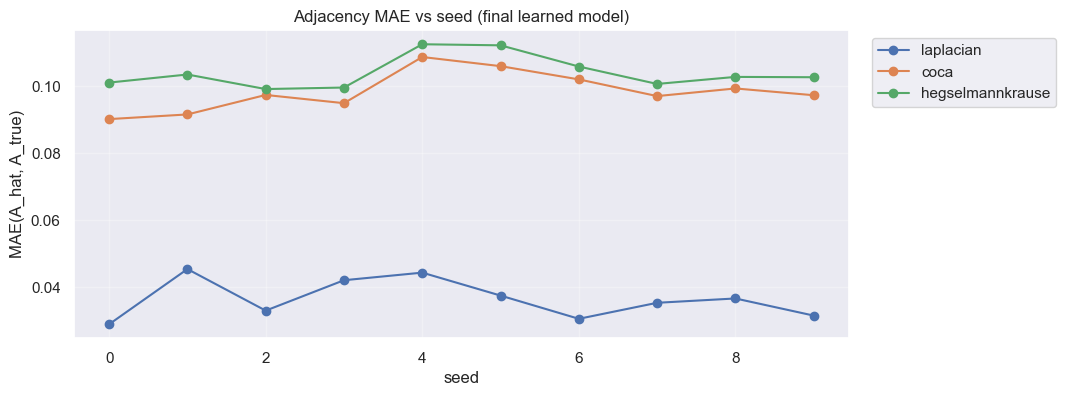

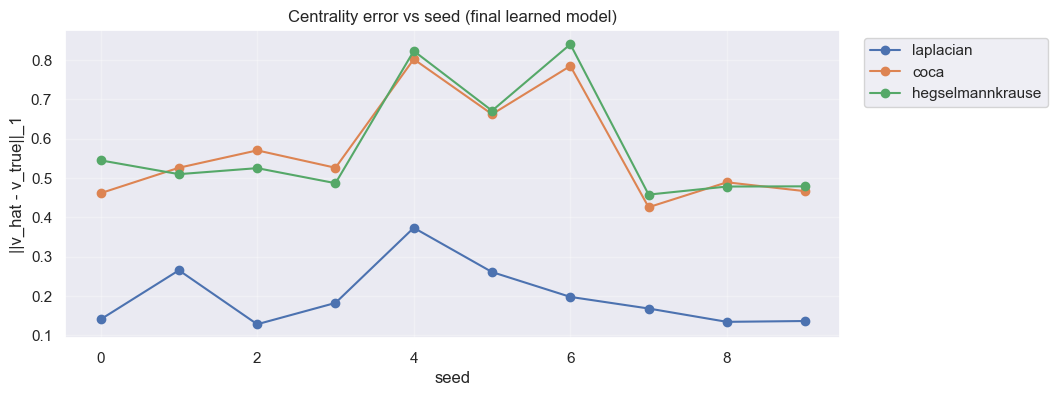

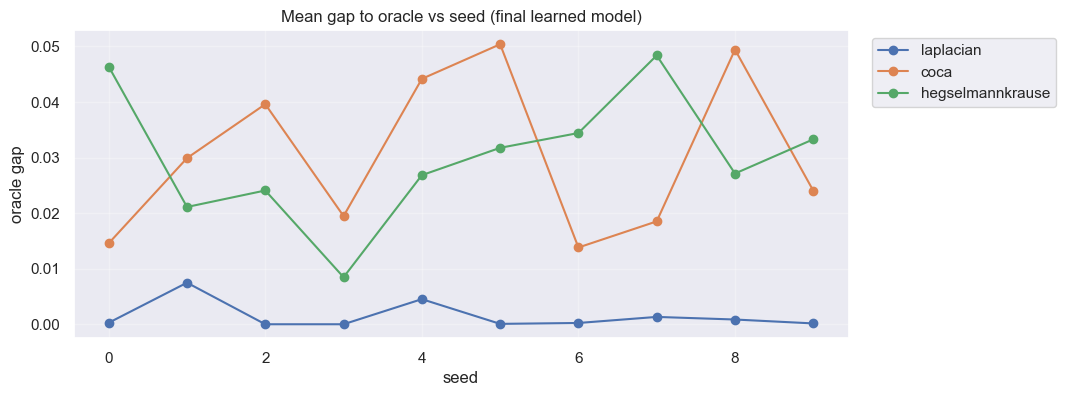

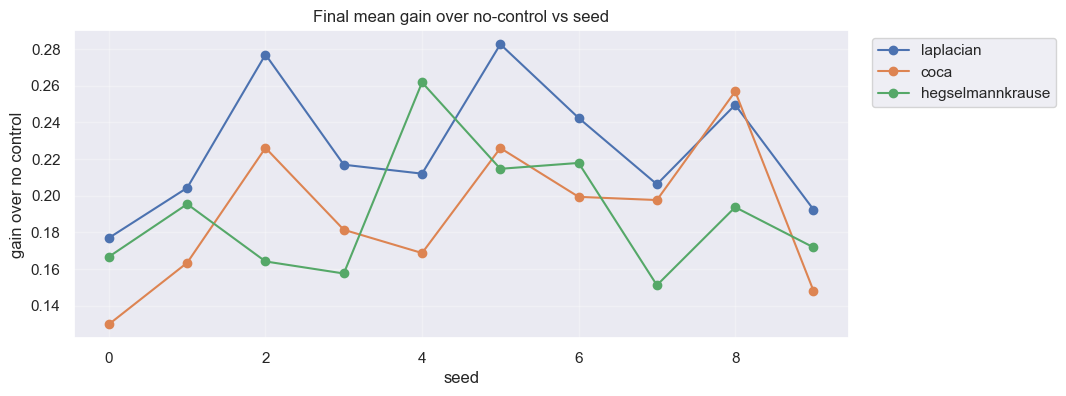

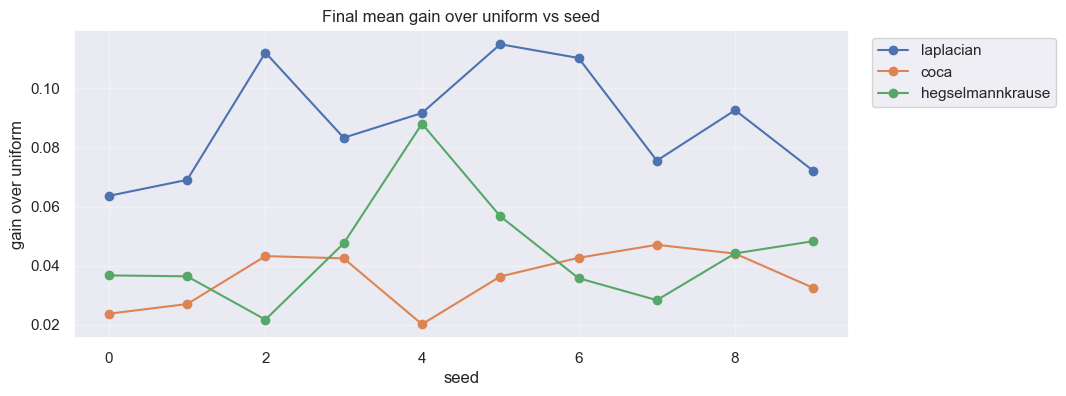

Per-repeat validation logs are available as df_learning and df_learning_by_dyn[dynamics].
Cached final models are available as final_models_by_dyn_seed[dynamics][seed].
Cached final artifacts are available as final_artifacts_by_dyn_seed[dynamics][seed].
Cached training initial states are available as train_x0s_by_dyn_seed[dynamics][seed].


In [17]:
# =========================================================
# Main experiment across propagation methods
# Learn from many one-campaign no-control rollouts.
# Evaluate final learned model under control.
# Cache ONLY the final resources needed downstream.
# =========================================================

final_models_by_dyn_seed = {}
final_metrics_by_dyn_seed = {}
final_artifacts_by_dyn_seed = {}
train_x0s_by_dyn_seed = {}
df_final_by_dyn = {}
df_learning_by_dyn = {}

dfs_final = []
dfs_learning = []

for dyn in DYNAMICS_LIST:
    print(f"=== Running {dyn} | learn from no-control single-campaign random inits ===")
    df_all, seed_cache = run_multi_seed_nocontrol_singlecampaign_experiment_dynamics(
        seeds=SEEDS,
        repeats_per_seed=NUM_REPEATS,
        dynamics_model=dyn,
        init_mode=INIT_MODE,
        learn_num_campaigns=LEARN_NUM_CAMPAIGNS,
        eval_num_campaigns=EVAL_NUM_CAMPAIGNS,
        B_campaign=B_CAMPAIGN,
        suppress_fit_logs=True,
        return_artifacts=True,
        identifier_kwargs=IDENTIFIER_KW,
        **FIT_BY_DYNAMICS[dyn],
    )

    # Keep the complete per-repeat validation log. This is the main learning curve:
    # one row per seed/repeat/dynamics, evaluated after each newly collected trial.
    df_all = add_trial_count_column(df_all)
    df_learning_by_dyn[dyn] = df_all.copy()
    dfs_learning.append(df_all.copy())

    final_models_by_dyn_seed[dyn] = {}
    final_metrics_by_dyn_seed[dyn] = {}
    final_artifacts_by_dyn_seed[dyn] = {}
    train_x0s_by_dyn_seed[dyn] = {}

    for seed in SEEDS:
        seed_out = seed_cache[int(seed)]
        final_models_by_dyn_seed[dyn][int(seed)] = seed_out["model_final"]
        final_metrics_by_dyn_seed[dyn][int(seed)] = seed_out["final_row"]
        final_artifacts_by_dyn_seed[dyn][int(seed)] = seed_out["final_artifact"]
        train_x0s_by_dyn_seed[dyn][int(seed)] = seed_out["train_x0s"]

    # We only keep the final repeat per seed for downstream summaries.
    df_final = (
        df_all.sort_values(["seed", "repeat"])
        .groupby("seed", as_index=False, group_keys=False)
        .tail(1)
        .reset_index(drop=True)
    )
    df_final_by_dyn[dyn] = df_final
    dfs_final.append(df_final)

    # Drop bulky intermediate objects as soon as possible.
    del seed_cache
    del df_all

df = pd.concat(dfs_final, axis=0).reset_index(drop=True)
df_learning = pd.concat(dfs_learning, axis=0).reset_index(drop=True)

display(df)

print("=== Per-repeat validation log available as df_learning ===")
print("Rows:", len(df_learning), "| columns:", len(df_learning.columns))
display(df_learning.head())

print("=== Aggregate by dynamics (final repeat only) ===")
cols = [
    "repeat",
    "train_pairs_total",
    "v_L1_final",
    "A_MAE_final",
    "mean_gap_to_oracle_end",
    "mean_gain_vs_noc_end",
    "mean_gain_vs_uniform_end",
    "vx_gap_to_oracle_end",
    "time_fit_inner",
]
display(df.groupby("dynamics")[cols].describe().T)

for metric, ylabel, title in [
    ("A_MAE_final", "MAE(A_hat, A_true)", "Adjacency MAE vs seed (final learned model)"),
    ("v_L1_final", "||v_hat - v_true||_1", "Centrality error vs seed (final learned model)"),
    ("mean_gap_to_oracle_end", "oracle gap", "Mean gap to oracle vs seed (final learned model)"),
    ("mean_gain_vs_noc_end", "gain over no control", "Final mean gain over no-control vs seed"),
    ("mean_gain_vs_uniform_end", "gain over uniform", "Final mean gain over uniform vs seed"),
]:
    plt.figure(figsize=(10, 4))
    for dyn in DYNAMICS_LIST:
        sub = df[df["dynamics"] == dyn].sort_values("seed")
        plt.plot(sub["seed"], sub[metric], marker="o", label=dyn)
    plt.xlabel("seed")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

print("Per-repeat validation logs are available as df_learning and df_learning_by_dyn[dynamics].")
print("Cached final models are available as final_models_by_dyn_seed[dynamics][seed].")
print("Cached final artifacts are available as final_artifacts_by_dyn_seed[dynamics][seed].")
print("Cached training initial states are available as train_x0s_by_dyn_seed[dynamics][seed].")


## Validation learning curves: how many no-control trials are enough?

This cell uses `df_learning`, which now stores validation metrics after each training trial. The criteria are editable in `DATA_NEED_CRITERIA`.

Validation rows: 3000
One row = one dynamics/seed/repeat validation checkpoint.


,dynamics,trial_count,mean_gap_to_oracle_end_mean,mean_gap_to_oracle_end_std,mean_gap_to_oracle_end_count,mean_gain_vs_uniform_end_mean,mean_gain_vs_uniform_end_std,mean_gain_vs_uniform_end_count,mean_gain_vs_noc_end_mean,mean_gain_vs_noc_end_std,...,A_MAE_final_std,A_MAE_final_count,v_L1_final_mean,v_L1_final_std,v_L1_final_count,mean_gap_to_oracle_end_sem,mean_gain_vs_uniform_end_sem,mean_gain_vs_noc_end_sem,A_MAE_final_sem,v_L1_final_sem
0,coca,1,0.037615,0.019494,10,0.028735,0.011557,10,0.182548,0.036730,...,0.005532,10,0.586434,0.136227,10,0.006165,0.003655,0.011615,0.001749,0.043079
1,coca,2,0.037346,0.019534,10,0.029004,0.011371,10,0.182816,0.036524,...,0.005533,10,0.586404,0.136197,10,0.006177,0.003596,0.011550,0.001750,0.043069
2,coca,3,0.037318,0.019515,10,0.029032,0.011332,10,0.182845,0.036508,...,0.005534,10,0.586353,0.136195,10,0.006171,0.003583,0.011545,0.001750,0.043069
3,coca,4,0.037318,0.019515,10,0.029032,0.011332,10,0.182845,0.036508,...,0.005537,10,0.586266,0.136175,10,0.006171,0.003583,0.011545,0.001751,0.043062
4,coca,5,0.037318,0.019515,10,0.029032,0.011332,10,0.182845,0.036508,...,0.005538,10,0.586179,0.136155,10,0.006171,0.003583,0.011545,0.001751,0.043056
5,coca,6,0.037318,0.019515,10,0.029032,0.011332,10,0.182845,0.036508,...,0.005541,10,0.586079,0.136127,10,0.006171,0.003583,0.011545,0.001752,0.043047
6,coca,7,0.037318,0.019515,10,0.029032,0.011332,10,0.182845,0.036508,...,0.005544,10,0.585959,0.136093,10,0.006171,0.003583,0.011545,0.001753,0.043036
7,coca,8,0.035788,0.016983,10,0.030562,0.010267,10,0.184375,0.037835,...,0.005547,10,0.585829,0.136088,10,0.005370,0.003247,0.011965,0.001754,0.043035
8,coca,9,0.035788,0.016983,10,0.030562,0.010267,10,0.184375,0.037835,...,0.005550,10,0.585696,0.136095,10,0.005370,0.003247,0.011965,0.001755,0.043037
9,coca,10,0.035727,0.016927,10,0.030623,0.010354,10,0.184436,0.037964,...,0.005552,10,0.585572,0.136107,10,0.005353,0.003274,0.012005,0.001756,0.043041


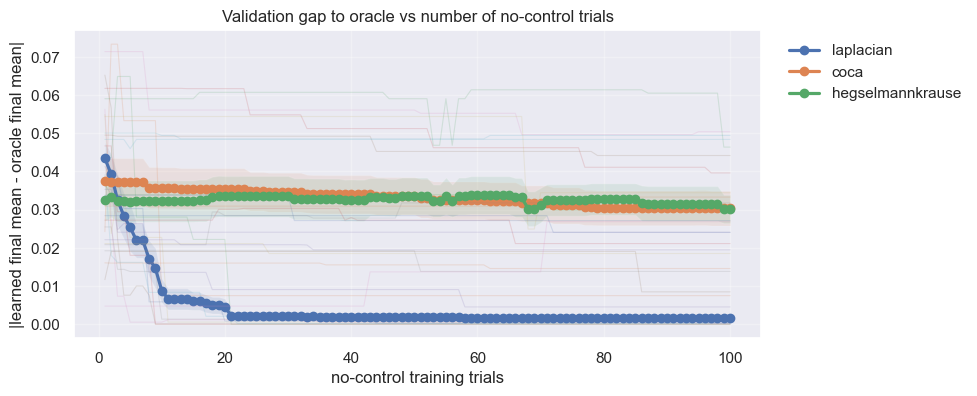

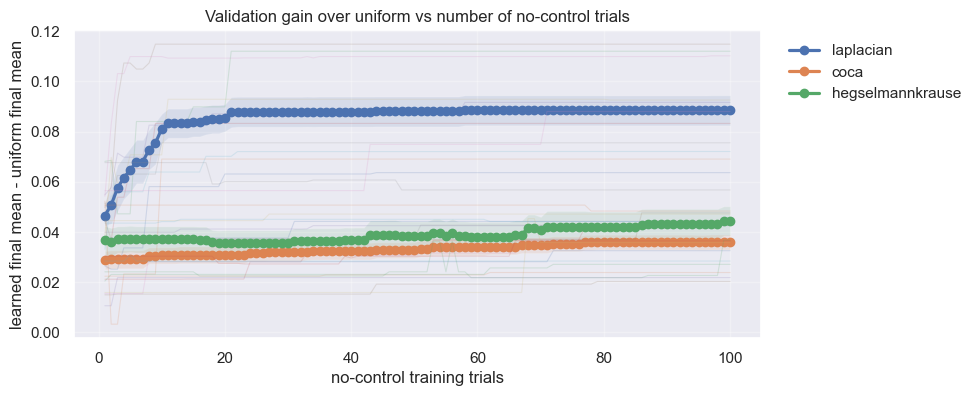

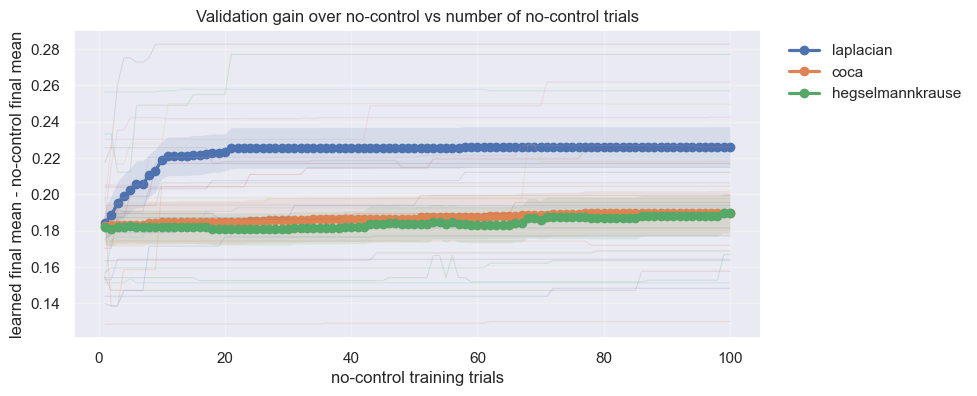

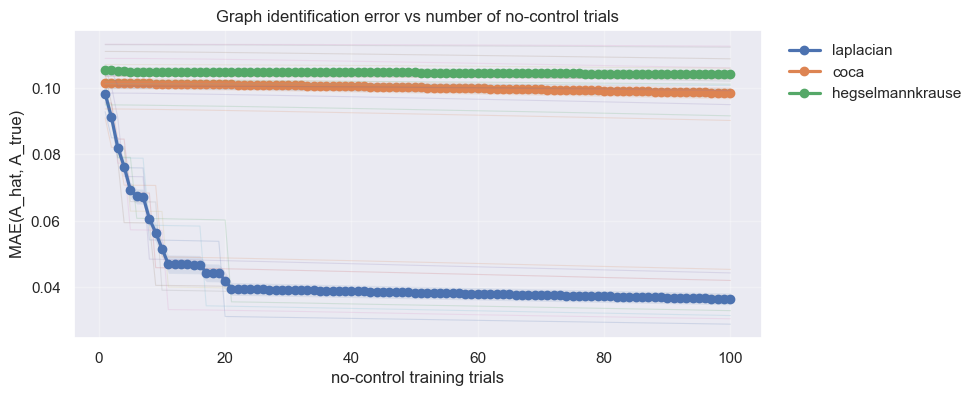

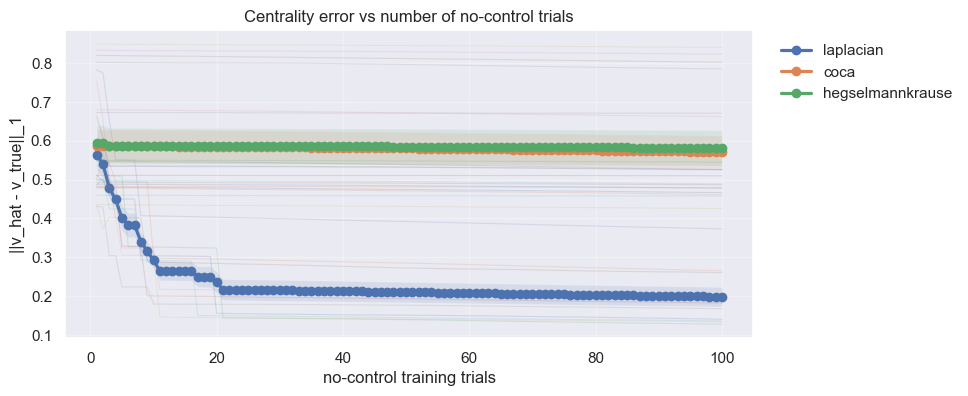

=== Data-need criteria ===
mean_gap_to_oracle_end <= 0.02
mean_gain_vs_uniform_end >= 0.0
=== First satisfying trial per seed ===


,dynamics,seed,trials_needed,train_pairs_needed,reached,mean_gap_to_oracle_end_at_hit,mean_gain_vs_uniform_end_at_hit,mean_gap_to_oracle_end_at_last,mean_gain_vs_uniform_end_at_last
0,coca,0,1.0,4.0,True,0.016057,0.022309,NaN,NaN
1,coca,1,NaN,NaN,False,NaN,NaN,0.029902,0.027049
2,coca,2,NaN,NaN,False,NaN,NaN,0.039609,0.043265
3,coca,3,34.0,136.0,True,0.019469,0.042486,NaN,NaN
4,coca,4,NaN,NaN,False,NaN,NaN,0.044170,0.020224
5,coca,5,NaN,NaN,False,NaN,NaN,0.050397,0.036366
6,coca,6,1.0,4.0,True,0.019219,0.037289,NaN,NaN
7,coca,7,27.0,108.0,True,0.018507,0.047095,NaN,NaN
8,coca,8,NaN,NaN,False,NaN,NaN,0.049429,0.044112
9,coca,9,NaN,NaN,False,NaN,NaN,0.024041,0.032504


=== Data need summary across seeds ===


,dynamics,seeds_total,seeds_reached,hit_rate,trials_needed_mean,trials_needed_median,trials_needed_p90,pairs_needed_median
0,coca,10,4,0.4,15.75,14.0,31.9,56.0
1,hegselmannkrause,10,2,0.2,1.00,1.0,1.0,4.0
2,laplacian,10,10,1.0,7.50,6.5,12.0,26.0


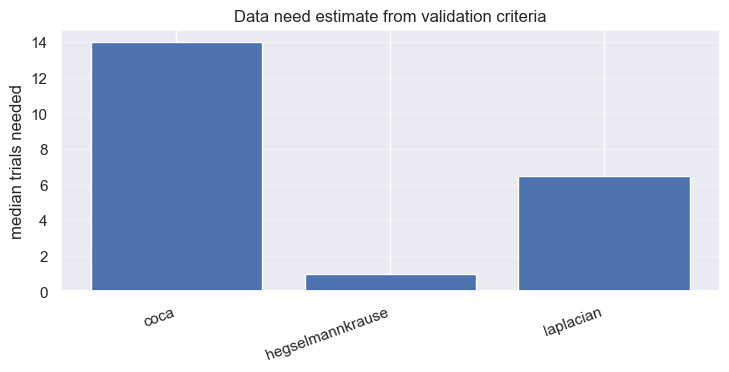

In [18]:
# =========================================================
# Analyze validation performance as a function of training data
# =========================================================

if "df_learning" not in globals():
    raise RuntimeError("Run the main experiment cell first so df_learning is available.")

print("Validation rows:", len(df_learning))
print("One row = one dynamics/seed/repeat validation checkpoint.")

learning_metrics = [
    "mean_gap_to_oracle_end",
    "mean_gain_vs_uniform_end",
    "mean_gain_vs_noc_end",
    "A_MAE_final",
    "v_L1_final",
]
learning_metrics = [m for m in learning_metrics if m in df_learning.columns]

curve_summary = aggregate_learning_curve(df_learning, metrics=learning_metrics)
display(curve_summary.head(20))

for metric, ylabel, title in [
    (
        "mean_gap_to_oracle_end",
        "|learned final mean - oracle final mean|",
        "Validation gap to oracle vs number of no-control trials",
    ),
    (
        "mean_gain_vs_uniform_end",
        "learned final mean - uniform final mean",
        "Validation gain over uniform vs number of no-control trials",
    ),
    (
        "mean_gain_vs_noc_end",
        "learned final mean - no-control final mean",
        "Validation gain over no-control vs number of no-control trials",
    ),
    (
        "A_MAE_final",
        "MAE(A_hat, A_true)",
        "Graph identification error vs number of no-control trials",
    ),
    (
        "v_L1_final",
        "||v_hat - v_true||_1",
        "Centrality error vs number of no-control trials",
    ),
]:
    if metric in df_learning.columns:
        plot_learning_curve_metric(df_learning, metric, ylabel=ylabel, title=title)

print("=== Data-need criteria ===")
for metric, (op, threshold) in DATA_NEED_CRITERIA.items():
    print(f"{metric} {op} {threshold}")

trials_needed_by_seed, trials_needed_summary = estimate_trials_needed(
    df_learning,
    DATA_NEED_CRITERIA,
)

print("=== First satisfying trial per seed ===")
display(trials_needed_by_seed.sort_values(["dynamics", "seed"]))

print("=== Data need summary across seeds ===")
display(trials_needed_summary.sort_values("dynamics"))
plot_trials_needed_summary(trials_needed_summary.sort_values("dynamics"))


## Optional robust sweep runner

Set `RUN_MULTI_X0_DATA_BUDGET_SWEEP = True` in the config cell to run this. It is intentionally separate from the default path because it retrains/evaluates additional validation initial states.

In [19]:
# =========================================================
# Optional: run the multi-validation-x0 data-budget sweep
# =========================================================

if RUN_MULTI_X0_DATA_BUDGET_SWEEP:
    df_data_budget = run_multi_seed_data_budget_sweep(
        seeds=DATA_BUDGET_SEEDS,
        dynamics_list=DATA_BUDGET_DYNAMICS_LIST,
        trial_counts=DATA_BUDGET_TRIAL_COUNTS,
        n_validation_x0=DATA_BUDGET_VALIDATION_X0S,
        init_mode=INIT_MODE,
        learn_num_campaigns=LEARN_NUM_CAMPAIGNS,
        eval_num_campaigns=EVAL_NUM_CAMPAIGNS,
        B_campaign=B_CAMPAIGN,
        device="cpu",
    )
    display(df_data_budget)

    for metric, ylabel, title in [
        ("mean_gap_to_oracle_end", "validation-set gap to oracle", "Multi-x0 validation gap to oracle"),
        ("mean_gain_vs_uniform_end", "validation-set gain over uniform", "Multi-x0 validation gain over uniform"),
        ("A_MAE_final", "MAE(A_hat, A_true)", "Multi-x0 sweep: graph error"),
        ("v_L1_final", "||v_hat - v_true||_1", "Multi-x0 sweep: centrality error"),
    ]:
        if metric in df_data_budget.columns:
            plot_learning_curve_metric(df_data_budget, metric, ylabel=ylabel, title=title, show_seed_traces=True)

    budget_needed_by_seed, budget_needed_summary = estimate_trials_needed(
        df_data_budget,
        DATA_NEED_CRITERIA,
    )
    display(budget_needed_by_seed.sort_values(["dynamics", "seed"]))
    display(budget_needed_summary.sort_values("dynamics"))
else:
    print("Skipped multi-x0 data-budget sweep. Set RUN_MULTI_X0_DATA_BUDGET_SWEEP = True to run it.")


Skipped multi-x0 data-budget sweep. Set RUN_MULTI_X0_DATA_BUDGET_SWEEP = True to run it.


In [20]:
# =========================================================
# Single-seed detailed runs for ALL dynamics
# Reuse the cached FINAL outputs from the main experiment cell.
# Uses local variables so notebook-wide config is not overwritten.
# =========================================================

seed_to_plot = int(globals().get("SEED_TO_PLOT"))
num_repeats_local = int(globals().get("NUM_REPEATS"))
dynamics_list_local = list(globals().get("DYNAMICS_LIST"))

outs_by_dyn = {}
metrics_by_dyn = {}
art_by_dyn = {}
model_by_dyn = {}

for dyn_name in dynamics_list_local:
    print("\n" + "=" * 80)
    print(f"=== DYNAMICS: {dyn_name} | SEED {seed_to_plot} ===")
    print("=" * 80)

    metrics = final_metrics_by_dyn_seed[dyn_name][int(seed_to_plot)]
    art = final_artifacts_by_dyn_seed[dyn_name][int(seed_to_plot)]
    model = final_models_by_dyn_seed[dyn_name][int(seed_to_plot)]
    train_x0s = train_x0s_by_dyn_seed[dyn_name][int(seed_to_plot)]

    outs_by_dyn[dyn_name] = {
        "train_x0s": train_x0s,
        "x0_eval": art["x0_eval"],
    }
    metrics_by_dyn[dyn_name] = metrics
    art_by_dyn[dyn_name] = art
    model_by_dyn[dyn_name] = model

    print(f"=== FINAL REPEAT {metrics['repeat'] + 1}/{num_repeats_local} ===")
    print(f"train_pairs_total: {metrics['train_pairs_total']}")
    print("=== METRICS ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")



=== DYNAMICS: laplacian | SEED 3 ===
=== FINAL REPEAT 100/100 ===
train_pairs_total: 400
=== METRICS ===
seed: 3
repeat: 99
repeat_seed: 1000003
dynamics: laplacian
init_mode: uniform
learn_num_campaigns: 1
eval_num_campaigns: 5
N: 15
train_pairs_total: 400
v_L1_final: 0.1820982145710816
A_Fro_final: 0.9599319920940108
A_MAE_final: 0.0420640093468169
mean_oracle_end: 0.7588969121419051
mean_learn_end: 0.7588969121063179
mean_noc_end: 0.5419949435982832
mean_uniform_end: 0.6756199355335678
mean_gap_to_oracle_end: 3.558719985363723e-11
mean_gain_vs_noc_end: 0.21690196850803478
mean_gain_vs_uniform_end: 0.08327697657275013
mean_err_avg: 4.6388855719688614e-11
mean_err_max: 8.689193808919526e-11
vx_gap_to_oracle_end: 3.291233952040784e-11
vx_err_avg: 3.3032188095916126e-11
vx_err_max: 4.6139980725001806e-11
time_fit_inner: 0.0070460999850183725
time_step_inner: 0.00014369981363415718
fit_calls_inner: 1
step_calls_inner: 1

=== DYNAMICS: coca | SEED 3 ===
=== FINAL REPEAT 100/100 ===
train


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: laplacian ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

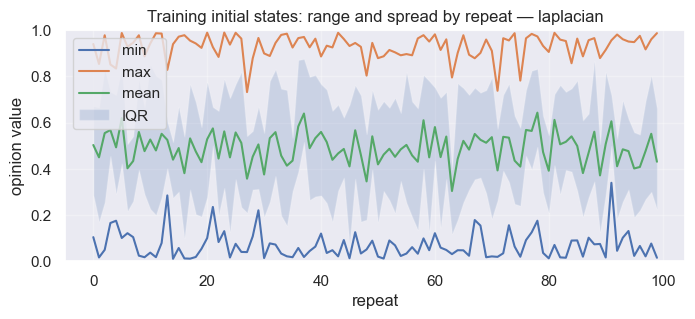

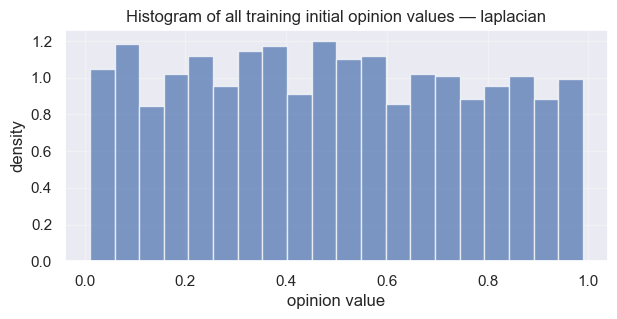

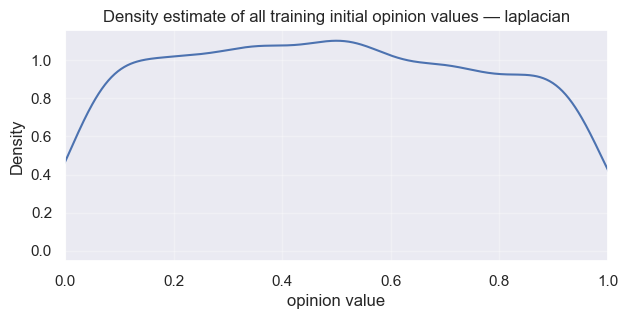

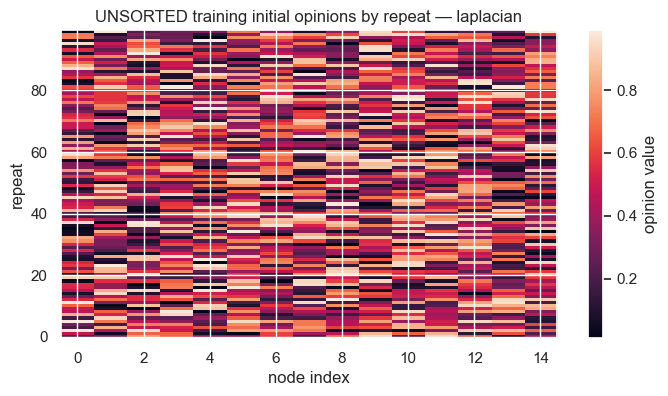

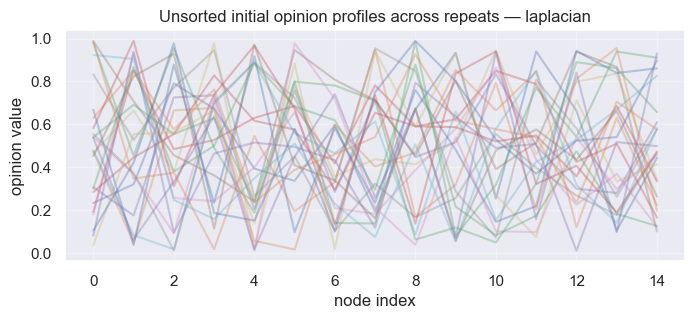


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: coca ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

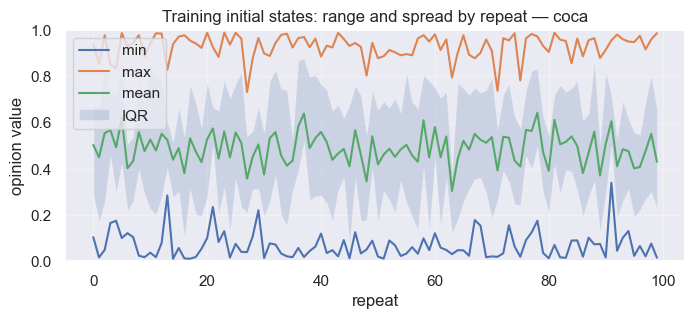

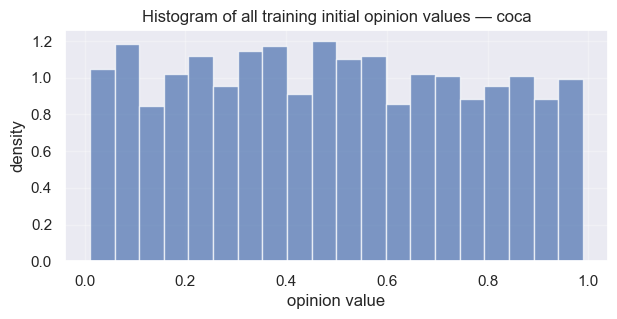

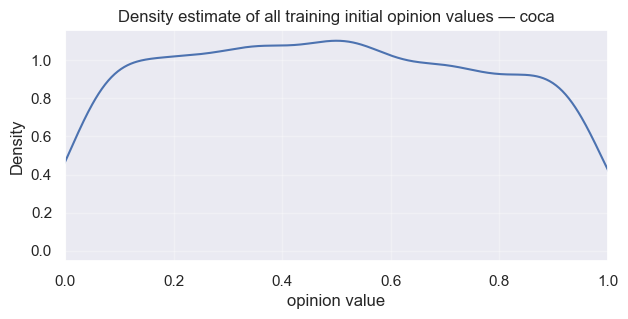

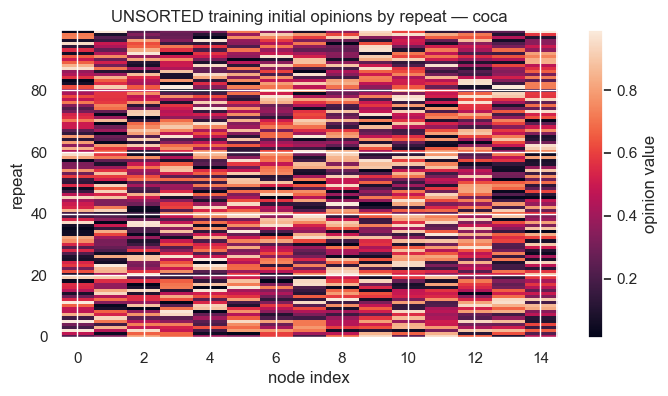

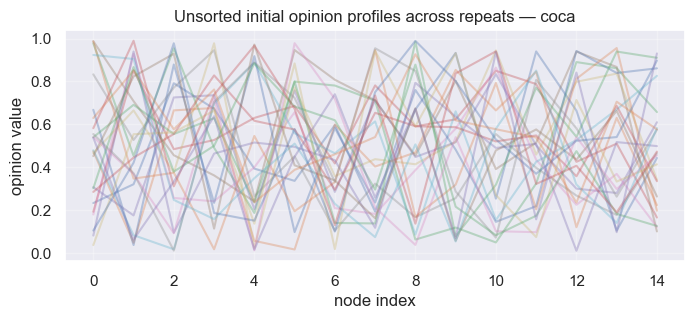


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: hegselmannkrause ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

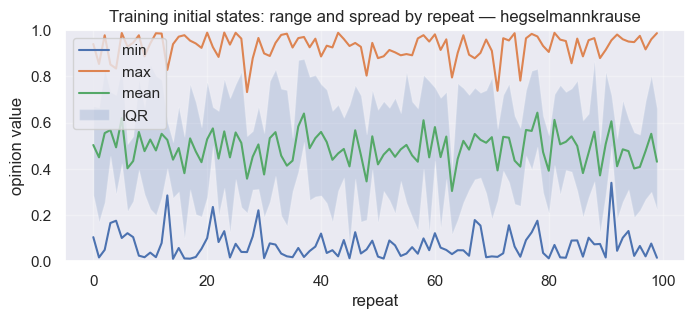

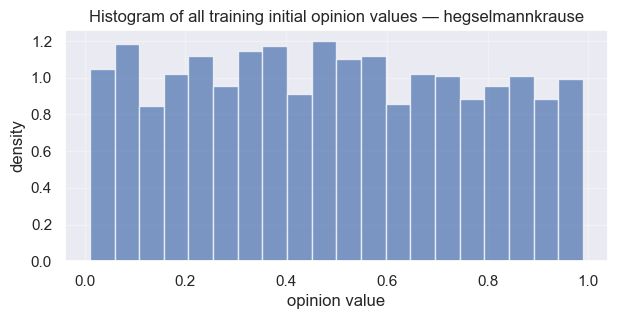

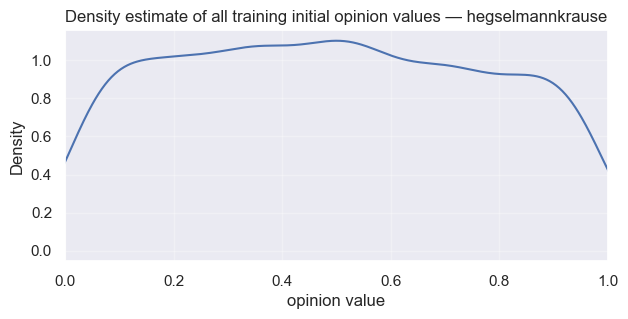

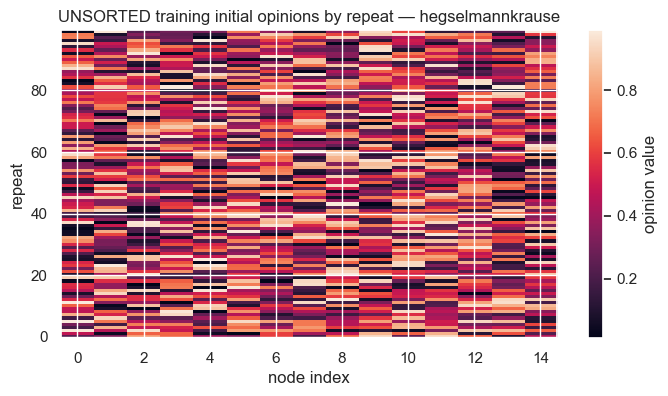

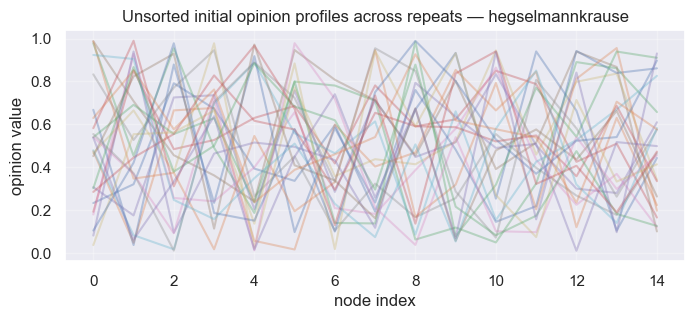

In [24]:
# =========================================================
# Sanity check: inspect the training initial states
# NOTE: uses the globally configured INIT_MODE and the cached train_x0s for the selected seed.
# =========================================================

for DYNAMICS in list(art_by_dyn.keys()):
    out = outs_by_dyn[DYNAMICS]
    all_x0_train = np.asarray(out["train_x0s"], dtype=float)
    summary_df = summarize_training_inits(all_x0_train)

    print("\n" + "-" * 80)
    print(f"=== TRAINING-INIT SANITY: {DYNAMICS} ===")
    print("-" * 80)
    display(summary_df.describe().T)

    flat = all_x0_train.ravel()
    print("Overall value summary:")
    display(pd.Series(flat).describe())

    plt.figure(figsize=(8, 3))
    plt.plot(summary_df["repeat"], summary_df["min"], label="min")
    plt.plot(summary_df["repeat"], summary_df["max"], label="max")
    plt.plot(summary_df["repeat"], summary_df["mean"], label="mean")
    plt.fill_between(summary_df["repeat"], summary_df["q25"], summary_df["q75"], alpha=0.2, label="IQR")
    plt.title(f"Training initial states: range and spread by repeat — {DYNAMICS}")
    plt.xlabel("repeat")
    plt.ylabel("opinion value")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.hist(flat, bins=20, density=True, alpha=0.7)
    plt.title(f"Histogram of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.ylabel("density")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 3))
    pd.Series(flat).plot(kind="density")
    plt.title(f"Density estimate of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.imshow(all_x0_train, aspect="auto", origin="lower")
    plt.colorbar(label="opinion value")
    plt.title(f"UNSORTED training initial opinions by repeat — {DYNAMICS}")
    plt.xlabel("node index")
    plt.ylabel("repeat")
    plt.show()

    plt.figure(figsize=(8, 3))
    for r in range(min(all_x0_train.shape[0], 25)):
        plt.plot(all_x0_train[r], alpha=0.35)
    plt.title(f"Unsorted initial opinion profiles across repeats — {DYNAMICS}")
    plt.xlabel("node index")
    plt.ylabel("opinion value")
    plt.grid(True, alpha=0.3)
    plt.show()


=== DETAILED ANALYSIS: laplacian | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999077990651
row_sum_mean: 1.0000000022351743
row_sum_max: 1.0000000623986125
asym: 0.7938806302852411
edges: 210
sink_sizes: [15]
has_singleton_sink: False


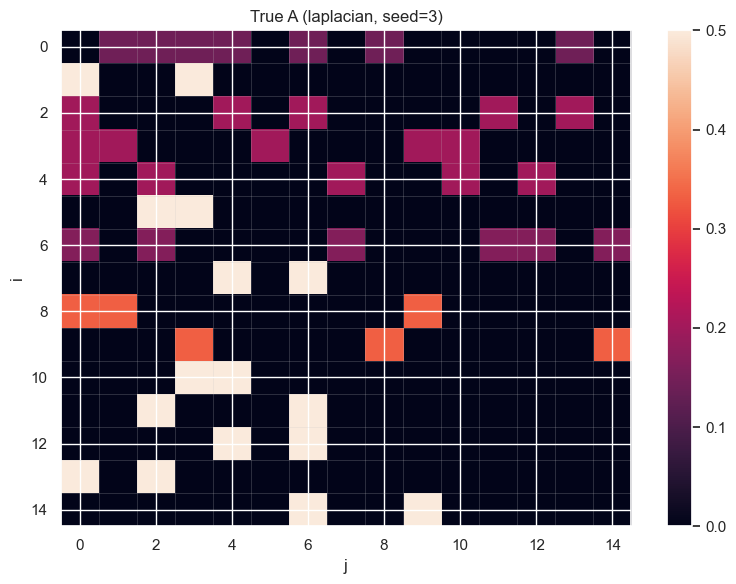

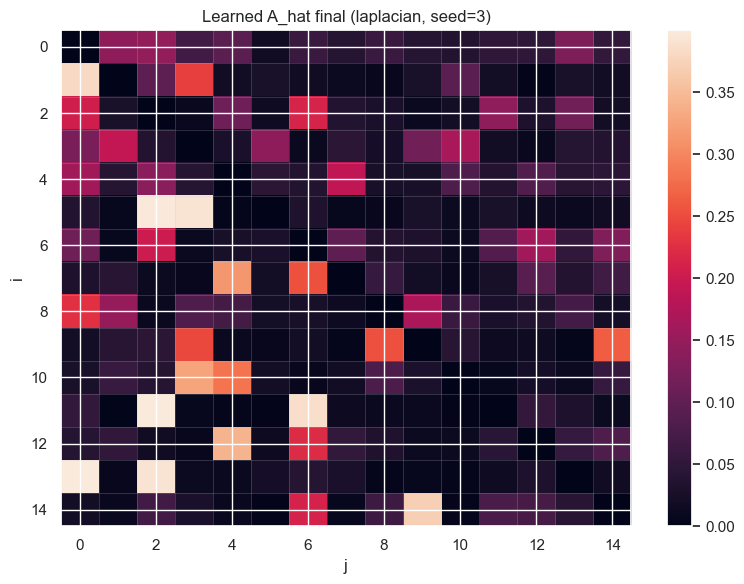


=== AUGMENTED TIME GRID CHECK ===
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
expected final campaign time: 10.0


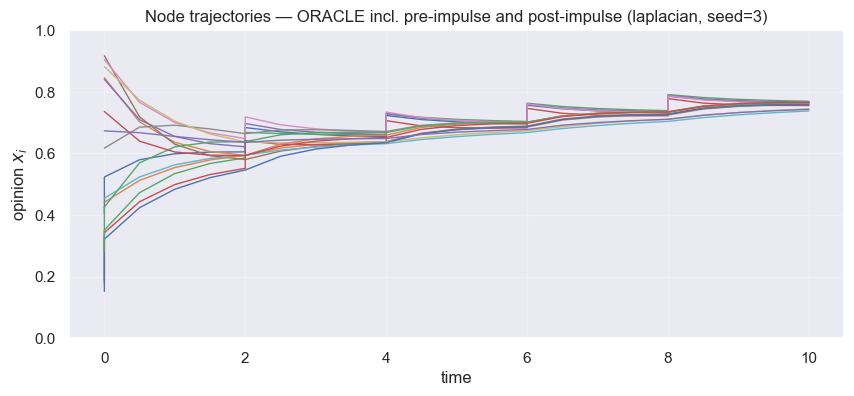

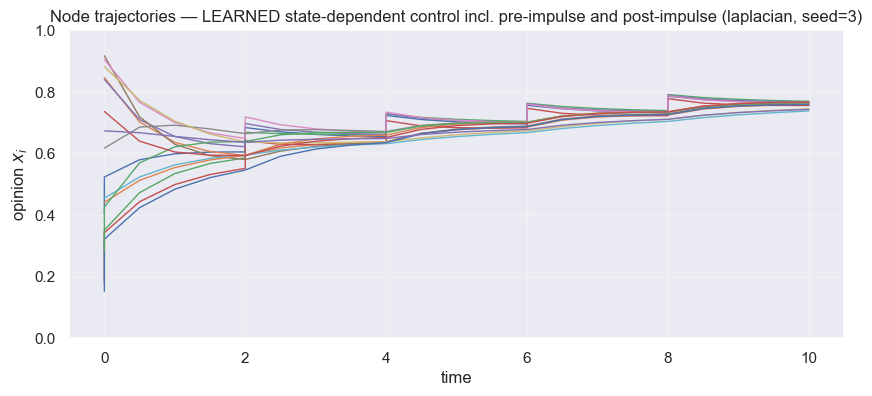


=== FAIRNESS CONVENTION ===
EVAL_ZERO_FIRST_CAMPAIGN: False
campaign-0 action sums: learned= 1.0 oracle= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 1.4901161193847656e-08

=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.1820982145710816
L1(v_eff at campaign 0 - v_true): 0.17864949168702265


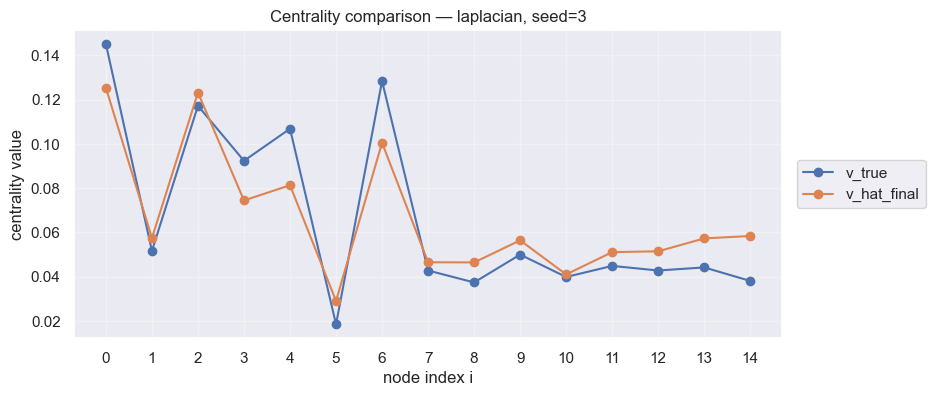

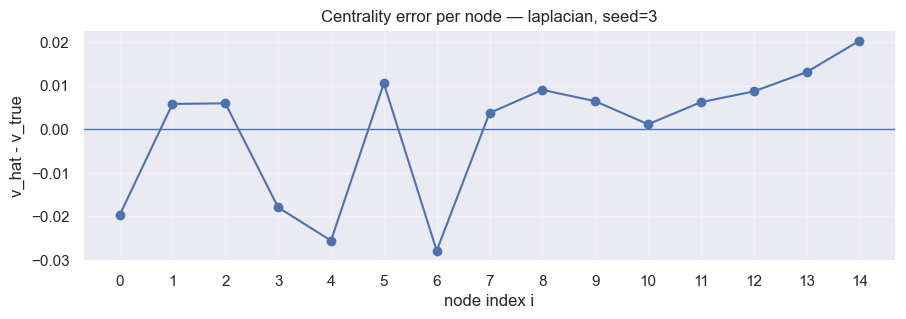

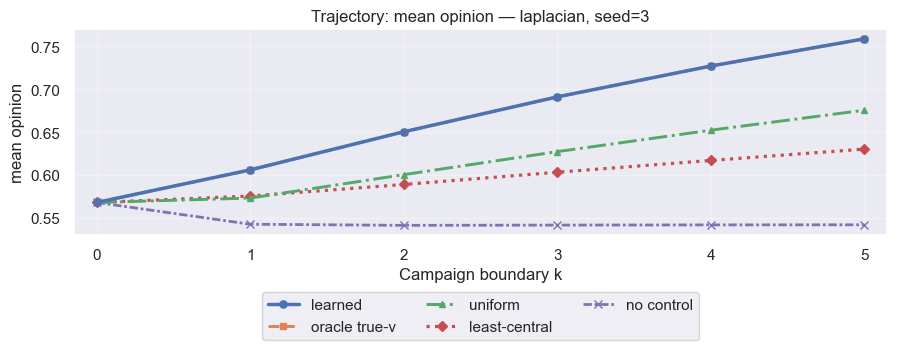


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 2.150702838044083e-09
learned states[1] vs nocontrol states[1] L_inf: 0.09078837150428198
learned final mean vs uniform final mean: 0.08327697657275013

=== DETAILED ANALYSIS: coca | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999292194843
row_sum_mean: 1.0000000045945248
row_sum_max: 1.0000000856816769
asym: 0.5786243305925124
edges: 

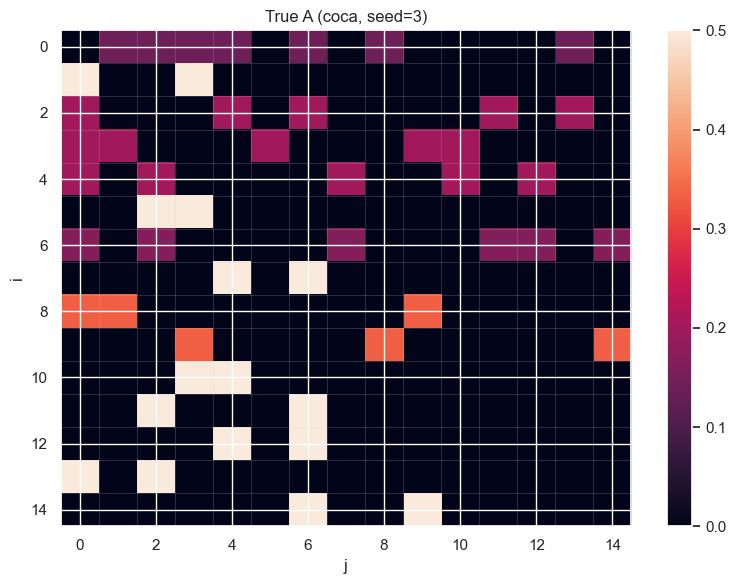

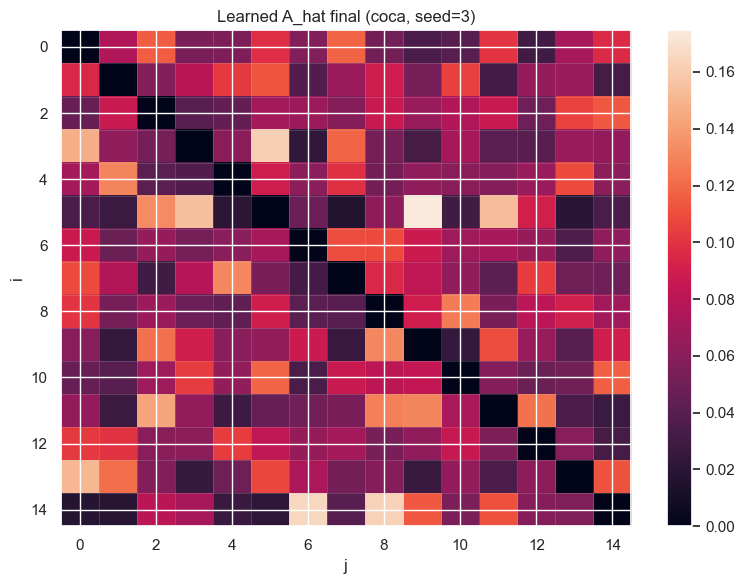


=== AUGMENTED TIME GRID CHECK ===
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
expected final campaign time: 10.0


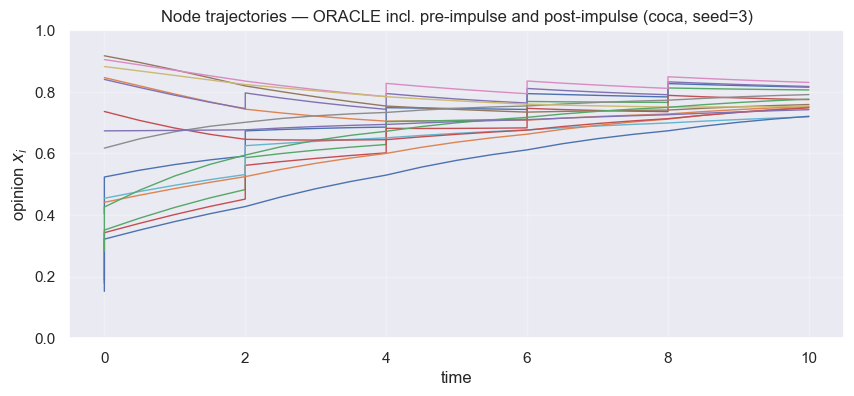

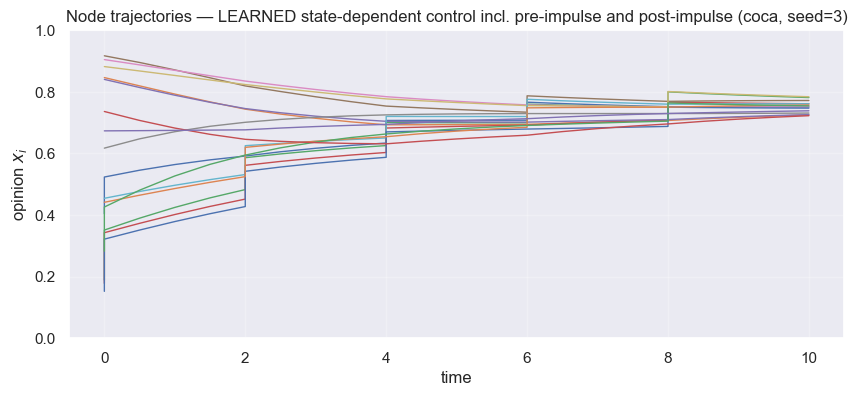


=== FAIRNESS CONVENTION ===
EVAL_ZERO_FIRST_CAMPAIGN: False
campaign-0 action sums: learned= 1.0 oracle= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 1.4901161193847656e-08

=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.5259369574864863
L1(v_eff at campaign 0 - v_true): 0.5085759014268874


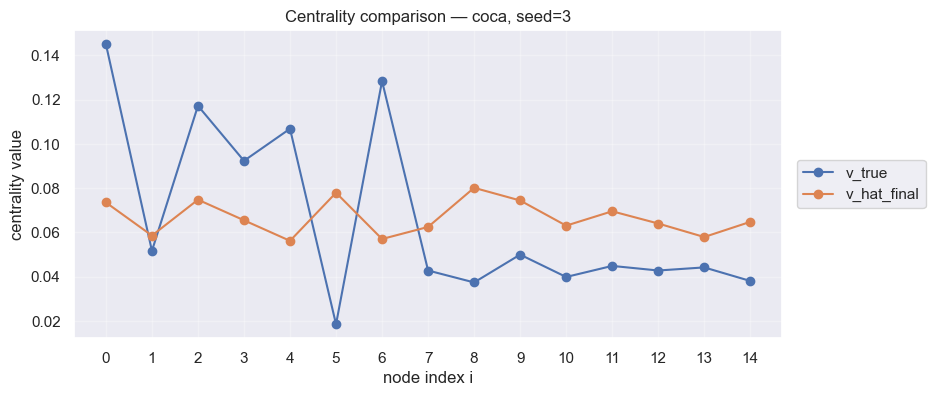

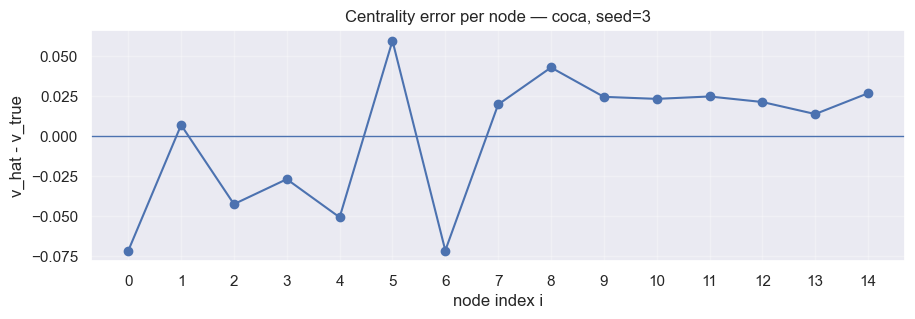

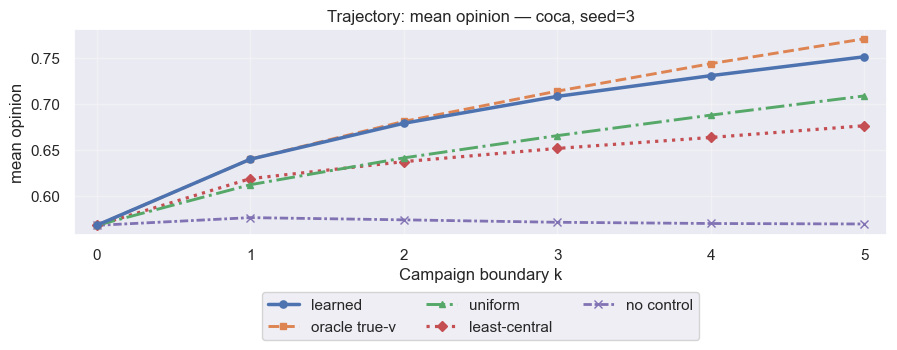


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 6.4290751611295605e-09
learned states[1] vs nocontrol states[1] L_inf: 0.17999329454599458
learned final mean vs uniform final mean: 0.04248637091790486

=== DETAILED ANALYSIS: hegselmannkrause | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999366700649
row_sum_mean: 0.999999996026357
row_sum_max: 1.000000111758709
asym: 0.5245355305575

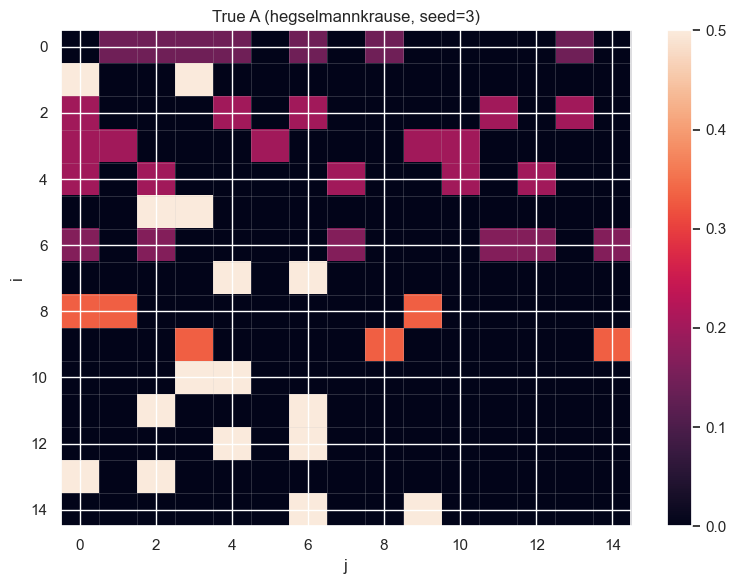

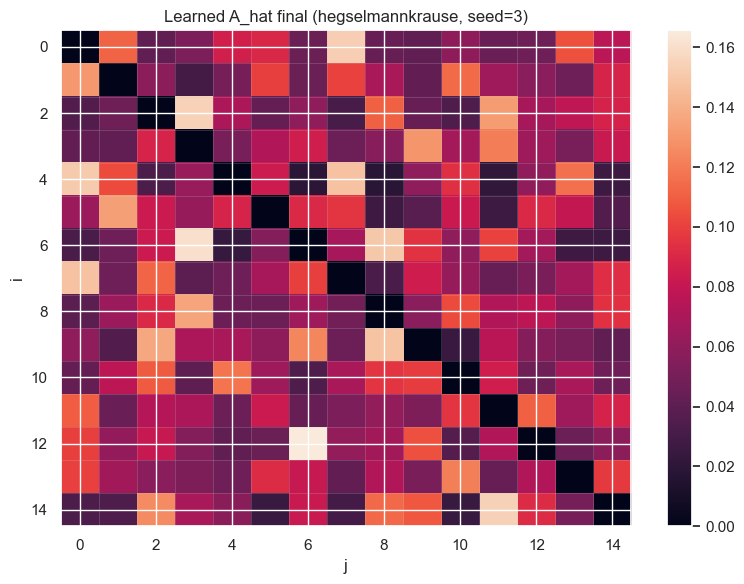


=== AUGMENTED TIME GRID CHECK ===
dt/t_s=0.5, t_campaign=2.0, campaigns=5
learned: T[0], T[-1], monotone: 0.0 10.0 True
oracle : T[0], T[-1], monotone: 0.0 10.0 True
expected final campaign time: 10.0


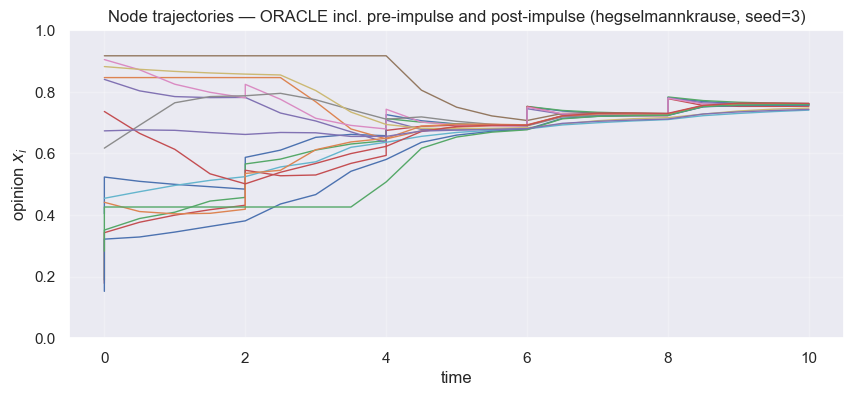

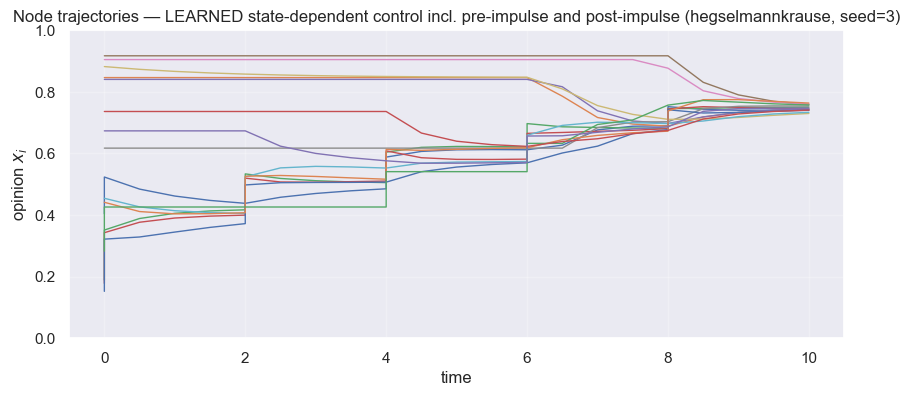


=== FAIRNESS CONVENTION ===
EVAL_ZERO_FIRST_CAMPAIGN: False
campaign-0 action sums: learned= 1.0 oracle= 1.0 uniform= 0.9999999999999999 nocontrol= 0.0
campaign-0 action L_inf learned-oracle: 1.4901161193847656e-08

=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.48669818420014366
L1(v_eff at campaign 0 - v_true): 0.4602109976490496


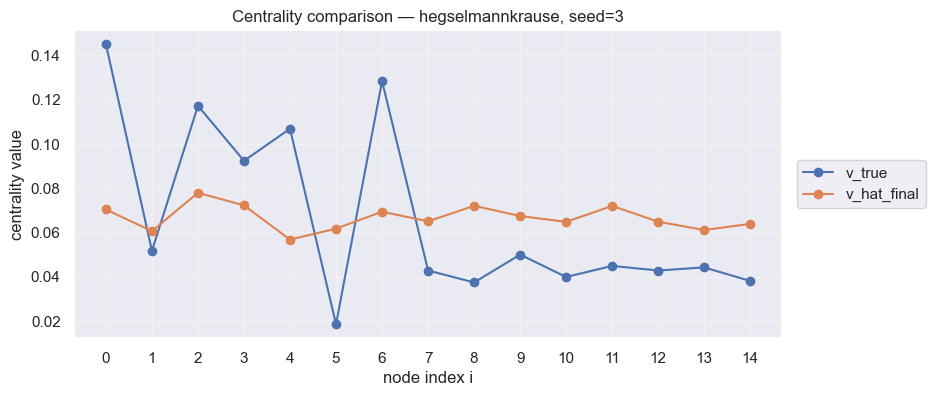

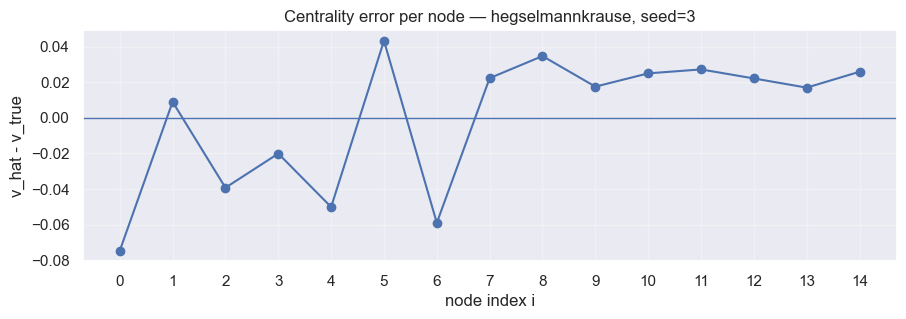

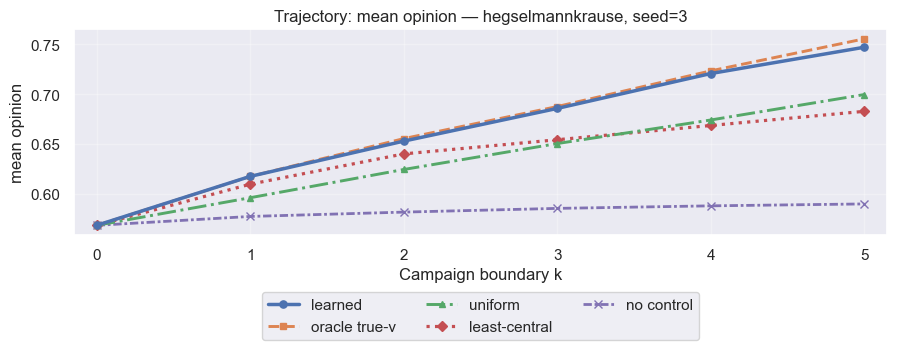


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.2349223886519104
learned states[1] vs nocontrol states[1] L_inf: 0.20426666760686996
learned final mean vs uniform final mean: 0.047583742435376775


In [27]:
# =========================================================
# Detailed graph / rollout comparison for the final learned model
# Run for ALL dynamics, as in the previous repeated notebook.
# =========================================================
env_factory = EnvironmentFactory()


# ---------------------------------------------------------
# Plot helpers for this diagnostic cell
# ---------------------------------------------------------
def _legend_outside(ax, *, loc="center left", anchor=(1.02, 0.5), ncol=1, frameon=True):
    """Put the legend outside the axes so it does not cover the data."""
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return None
    return ax.legend(
        handles,
        labels,
        loc=loc,
        bbox_to_anchor=anchor,
        ncol=ncol,
        frameon=frameon,
        borderaxespad=0.0,
    )


def plot_mean_baseline_comparison(mean_series, title, *args, **kwargs):
    """
    Clear mean/baseline comparison plot.

    The legend is kept, but moved outside the axes.  Overlapping curves are
    distinguished using line style + marker shape, so the legend directly maps
    visual style to baseline name.
    """
    mean_series = {k: np.asarray(v, dtype=float) for k, v in mean_series.items()}
    first = next(iter(mean_series.values()))
    x = np.arange(first.shape[0])

    style_cycle = [
        dict(marker="o", linestyle="-",  linewidth=2.5, markersize=5.2, zorder=5),
        dict(marker="s", linestyle="--", linewidth=2.1, markersize=5.0, zorder=4),
        dict(marker="^", linestyle="-.", linewidth=2.1, markersize=5.0, zorder=3),
        dict(marker="D", linestyle=":",  linewidth=2.3, markersize=4.8, zorder=2),
        dict(marker="x", linestyle=(0, (3, 1, 1, 1)), linewidth=2.0, markersize=5.4, zorder=1),
    ]

    fig, ax = plt.subplots(figsize=(10.5, 3.8))
    for (label, y), style in zip(mean_series.items(), style_cycle):
        ax.plot(x, y, label=label, **style)

    ax.set_xlabel("Campaign boundary k")
    ax.set_ylabel("mean opinion")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(x)
    ax.margins(x=0.03)

    # Keep the legend visible, but outside the data region.
    _legend_outside(
        ax,
        loc="upper center",
        anchor=(0.5, -0.28),
        ncol=min(3, max(1, len(mean_series))),
        frameon=True,
    )
    fig.subplots_adjust(bottom=0.34)
    plt.show()

for DYNAMICS in list(art_by_dyn.keys()):
    art = art_by_dyn[DYNAMICS]

    A_true = np.asarray(art["A_true"], dtype=float)
    v_true = np.asarray(art["v_true"], dtype=float)
    A_hat_final = np.asarray(art["A_hat_final"], dtype=float)
    v_hat_final = np.asarray(art["v_hat_final"], dtype=float)

    x0_train = np.asarray(art["x0_train"], dtype=float)
    x0_eval = np.asarray(art["x0_eval"], dtype=float)

    states_learn = np.asarray(art["states_learn"], dtype=float)
    states_oracle = np.asarray(art["states_oracle"], dtype=float)
    states_noc = np.asarray(art["states_nocontrol_eval"], dtype=float)
    states_uniform = np.asarray(art["states_uniform_eval"], dtype=float)
    N = states_learn.shape[1]
    K_total = states_learn.shape[0] - 1

    print("\n" + "=" * 80)
    print(f"=== DETAILED ANALYSIS: {DYNAMICS} | SEED {seed_to_plot} ===")
    print("=" * 80)
    print("x0_train:", x0_train)
    print("x0_eval :", x0_eval)

    print("\n=== GRAPH SANITY (TRUE) ===")
    for k, v in graph_sanity(A_true).items():
        print(f"{k}: {v}")

    print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
    for k, v in graph_sanity(A_hat_final).items():
        print(f"{k}: {v}")

    show_matrix_with_cell_grid(
        A_true,
        title=f"True A ({DYNAMICS}, seed={seed_to_plot})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )
    show_matrix_with_cell_grid(
        A_hat_final,
        title=f"Learned A_hat final ({DYNAMICS}, seed={seed_to_plot})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )

    env_template = make_env_with_dynamics(
        env_factory,
        seed=seed_to_plot,
        dynamics_model=DYNAMICS,
    )

    env_learn, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_or, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_nc, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_uni, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )

    le_out = rollout_with_model_derived_control_intermediate(
        env_learn,
        model_by_dyn[DYNAMICS],
        x0_eval,
        K_total,
        B_CAMPAIGN,
        device="cpu",
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )
    or_out = rollout_with_v_intermediate(
        env_or, x0_eval, K_total, B_CAMPAIGN, v_true,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )
    nc_out = rollout_with_v_intermediate(
        env_nc, x0_eval, K_total, B_CAMPAIGN, None,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )
    uni_out = rollout_with_uniform_intermediate(
        env_uni, x0_eval, K_total, B_CAMPAIGN,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )

    order = np.argsort(v_true)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(v_true) + 1)
    v_anti = 1.0 / ranks
    v_anti = v_anti / v_anti.sum()

    env_anti, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    anti_out = rollout_with_v_intermediate(
        env_anti, x0_eval, K_total, B_CAMPAIGN, v_anti,
        zero_first_campaign=EVAL_ZERO_FIRST_CAMPAIGN,
    )

    # Boundary-level states for checks and summary plots
    states_learn_eval = np.asarray(le_out["states"], dtype=float)
    states_or_eval = np.asarray(or_out["states"], dtype=float)
    states_nc_eval = np.asarray(nc_out["states"], dtype=float)
    states_anti_eval = np.asarray(anti_out["states"], dtype=float)
    states_uni_eval = np.asarray(uni_out["states"], dtype=float)

    dt = float(getattr(env_template, "t_s", 1.0))
    t_campaign = float(getattr(env_template, "t_campaign", dt))
    desired_opinion = float(getattr(env_template, "desired_opinion", 1.0))

    X_le, T_le = build_augmented_campaign_trajectory(
        states_learn_eval,
        np.asarray(le_out["actions"], dtype=float),
        le_out["intermediate_states_list"],
        desired_opinion=desired_opinion,
        dt=dt,
        t_campaign=t_campaign,
    )
    X_or, T_or = build_augmented_campaign_trajectory(
        states_or_eval,
        np.asarray(or_out["actions"], dtype=float),
        or_out["intermediate_states_list"],
        desired_opinion=desired_opinion,
        dt=dt,
        t_campaign=t_campaign,
    )

    print("\n=== AUGMENTED TIME GRID CHECK ===")
    print(f"dt/t_s={dt}, t_campaign={t_campaign}, campaigns={K_total}")
    print("learned: T[0], T[-1], monotone:", float(T_le[0]), float(T_le[-1]), bool(np.all(np.diff(T_le) >= -1e-9)))
    print("oracle : T[0], T[-1], monotone:", float(T_or[0]), float(T_or[-1]), bool(np.all(np.diff(T_or) >= -1e-9)))
    print("expected final campaign time:", float(K_total * t_campaign))

    plot_impulse_node_trajectories(
        X_or,
        T_or,
        title=f"Node trajectories — ORACLE incl. pre-impulse and post-impulse ({DYNAMICS}, seed={seed_to_plot})",
    )
    plot_impulse_node_trajectories(
        X_le,
        T_le,
        title=f"Node trajectories — LEARNED state-dependent control incl. pre-impulse and post-impulse ({DYNAMICS}, seed={seed_to_plot})",
    )

    print("\n=== FAIRNESS CONVENTION ===")
    print("EVAL_ZERO_FIRST_CAMPAIGN:", EVAL_ZERO_FIRST_CAMPAIGN)
    print("campaign-0 action sums:",
          "learned=", float(np.asarray(le_out["actions"])[0].sum()),
          "oracle=", float(np.asarray(or_out["actions"])[0].sum()),
          "uniform=", float(np.asarray(uni_out["actions"])[0].sum()),
          "nocontrol=", float(np.asarray(nc_out["actions"])[0].sum()))
    print("campaign-0 action L_inf learned-oracle:",
          float(np.max(np.abs(np.asarray(le_out["actions"])[0] - np.asarray(or_out["actions"])[0]))))

    print("\n=== INITIAL-STATE / IMPULSE CHECK ===")
    print("L_inf(common x0_eval - learned boundary state[0]):", float(np.max(np.abs(x0_eval - states_learn_eval[0]))))
    print("L_inf(common x0_eval - oracle boundary state[0]):", float(np.max(np.abs(x0_eval - states_or_eval[0]))))
    print("L_inf(learned boundary state[0] - oracle boundary state[0]):", float(np.max(np.abs(states_learn_eval[0] - states_or_eval[0]))))
    print("Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.")

    print("\n=== CENTRALITY COMPARISON (by node index) ===")
    print("L1(v_hat_final - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))
    if art.get("learned_effective_centralities"):
        v_eff0 = np.asarray(art["learned_effective_centralities"][0], dtype=float)
        print("L1(v_eff at campaign 0 - v_true):", float(np.sum(np.abs(v_eff0 - v_true))))

    idx = np.arange(N)
    diff = v_hat_final - v_true

    fig, ax = plt.subplots(figsize=(10.5, 4))
    ax.plot(idx, v_true, marker="o", label="v_true")
    ax.plot(idx, v_hat_final, marker="o", label="v_hat_final")
    ax.set_xlabel("node index i")
    ax.set_ylabel("centrality value")
    ax.set_title(f"Centrality comparison — {DYNAMICS}, seed={seed_to_plot}")
    ax.set_xticks(idx)
    ax.grid(True, alpha=0.3)
    _legend_outside(ax)
    fig.subplots_adjust(right=0.80)
    plt.show()

    fig, ax = plt.subplots(figsize=(10.5, 3))
    ax.axhline(0.0, linewidth=1)
    ax.plot(idx, diff, marker="o")
    ax.set_xlabel("node index i")
    ax.set_ylabel("v_hat - v_true")
    ax.set_title(f"Centrality error per node — {DYNAMICS}, seed={seed_to_plot}")
    ax.set_xticks(idx)
    ax.grid(True, alpha=0.3)
    plt.show()

    mean_learn = states_learn_eval.mean(axis=1)
    mean_or = states_or_eval.mean(axis=1)
    mean_nc = states_nc_eval.mean(axis=1)
    mean_uni = states_uni_eval.mean(axis=1)
    mean_anti = states_anti_eval.mean(axis=1)

    plot_mean_baseline_comparison(
        {
            "learned": mean_learn,
            "oracle true-v": mean_or,
            "uniform": mean_uni,
            "least-central": mean_anti,
            "no control": mean_nc,
        },
        title=f"Trajectory: mean opinion — {DYNAMICS}, seed={seed_to_plot}",
    )

    print("\n=== CAMPAIGN-0 OVERLAP CHECK ===")
    print(
        "learned states[1] vs oracle states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_or_eval[1]))),
    )
    print(
        "learned states[1] vs nocontrol states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_nc_eval[1]))),
    )

    print("learned final mean vs uniform final mean:",
          float(mean_learn[-1] - mean_uni[-1]))
